# Hyperparameter Analysis

results are loaded from pre-computed CSV sweeps in results/hyperparameters/.

Algorithms covered:
- One-Class SVM (nu, kernel, gamma)
- Isolation Forest (n_estimators, contamination, max_features)
- Local Outlier Factor (n_neighbors, metric, contamination)
- DBSCAN (eps, min_samples, 2D grid)
- ECOD (contamination - parameter-free baseline)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

HP_DIR = Path('results/hyperparameters')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130})

METRICS  = ['auc_roc', 'auc_pr', 'f1']
METRIC_LABELS = {'auc_roc': 'AUC-ROC', 'auc_pr': 'AUC-PR', 'f1': 'F1'}
RED, AMBER, GREEN = '#d73027', '#fee090', '#91cf60'


## Helper Functions

In [3]:
def load_sweep(algo: str, fname: str) -> pd.DataFrame:
    return pd.read_csv(HP_DIR / algo / fname)

def plot_sweep_lines(df, param_col, metric='auc_roc', title='', log_x=False, annotate_best=True):
    """
    One line per dataset.  Shaded band = +-1 std where available.
    """
    std_col = metric + '_std'
    datasets = df['dataset'].unique()
    palette = sns.color_palette('tab10', len(datasets))

    fig, ax = plt.subplots(figsize=(13, 5))
    for ds, color in zip(datasets, palette):
        sub = df[df['dataset'] == ds].sort_values(param_col)
        x, y = sub[param_col].values, sub[metric].values
        ax.plot(x, y, marker='o', label=ds, color=color, lw=2)
        if std_col in sub.columns:
            std = sub[std_col].values
            ax.fill_between(x, y - std, y + std, alpha=0.13, color=color)
        if annotate_best:
            best_i = np.argmax(y)
            ax.annotate(f'{y[best_i]:.2f}', xy=(x[best_i], y[best_i]), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=7.5, 
                        color=color, fontweight='bold')

    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(param_col, fontsize=12)
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    plt.tight_layout()
    return fig


def plot_delta_from_best(df, param_col, metric='auc_roc', title=''):
    """
    Shows the cost of each parameter value: how far each dataset is from its own best score.  Zero = optimal; higher = worse.
    """
    tmp = df.copy()
    best = tmp.groupby('dataset')[metric].transform('max')
    tmp['delta'] = best - tmp[metric]
    order = sorted(tmp[param_col].unique())

    fig, ax = plt.subplots(figsize=(13, 4))
    sns.boxplot(data=tmp, x=param_col, y='delta', order=order, palette='Blues_r', width=0.5, ax=ax)
    sns.stripplot(data=tmp, x=param_col, y='delta', order=order, color='#333333', alpha=0.45, size=4.5, jitter=True, ax=ax)

    ax.axhline(0, color='seagreen', lw=1.5, ls='--', label='optimal (no loss)')
    ax.set_ylabel('Performance drop from best(↓ lower is better)', fontsize=11)
    ax.set_xlabel(param_col, fontsize=12)
    ax.set_title(title or f'Cost of {param_col} choice (delta from best {METRIC_LABELS.get(metric, metric)})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    return fig

def plot_sweep_heatmap(df, param_col, metric='auc_roc', cmap='RdYlGn', title=''):
    """
    Each row = one dataset; each column = one parameter value.
    """
    pivot = (df.pivot_table(index='dataset', columns=param_col, values=metric, aggfunc='mean').sort_index())
    fig, ax = plt.subplots(figsize=(max(10, pivot.shape[1] * 1.4), max(5, pivot.shape[0] * 0.55)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap, linewidths=0.4, cbar_kws={'label': METRIC_LABELS.get(metric, metric)}, vmin=0, vmax=1, ax=ax)
    ax.set_title(title or f'{METRIC_LABELS.get(metric, metric)} across {param_col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(param_col, fontsize=11)
    ax.set_ylabel('Dataset', fontsize=11)
    plt.tight_layout()
    return fig


def plot_metrics_boxplots(df, param_col, metrics, title=''):
    """Boxplots of metric scores across categorical param values, per dataset."""    
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.5 * len(metrics), 4), sharey=False)
    if len(metrics) == 1:
        axes = [axes]
    order = sorted(df[param_col].unique())
    for ax, metric in zip(axes, metrics):
        sns.boxplot(data=df, x=param_col, y=metric, order=order, palette='pastel', width=0.55, ax=ax)
        sns.stripplot(data=df, x=param_col, y=metric, order=order, color='#333', alpha=0.35, size=4, jitter=True, ax=ax)
        ax.set_title(METRIC_LABELS.get(metric, metric), fontsize=12, fontweight='bold')
        ax.set_xlabel(param_col, fontsize=11)
        ax.set_ylabel('Score', fontsize=10)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    fig.tight_layout()
    return fig


def sensitivity_table(df, param_col, metric='auc_roc') -> pd.DataFrame:
    """
    Per-dataset sensitivity: range (max-min) and std of metric across param values.
    High range -> sensitive to param; low range -> stable.
    """
    return (
        df.groupby('dataset')[metric]
        .agg(mean='mean', std='std', range=lambda x: x.max() - x.min())
        .sort_values('range', ascending=False)
        .round(4)
    )


def global_sensitivity(sweeps: dict, metric='auc_roc') -> pd.DataFrame:
    rows = []
    for algo, (df, param_col) in sweeps.items():
        tbl = sensitivity_table(df, param_col, metric)
        rows.append({'Algorithm': algo, 'Parameter': param_col,  'Mean AUC-ROC': df[metric].mean(),
                     'Mean range': tbl['range'].mean(), 'Mean std':   tbl['std'].mean()})
    return pd.DataFrame(rows).sort_values('Mean range', ascending=False).round(4)


---
## One-Class SVM

### nu sweep


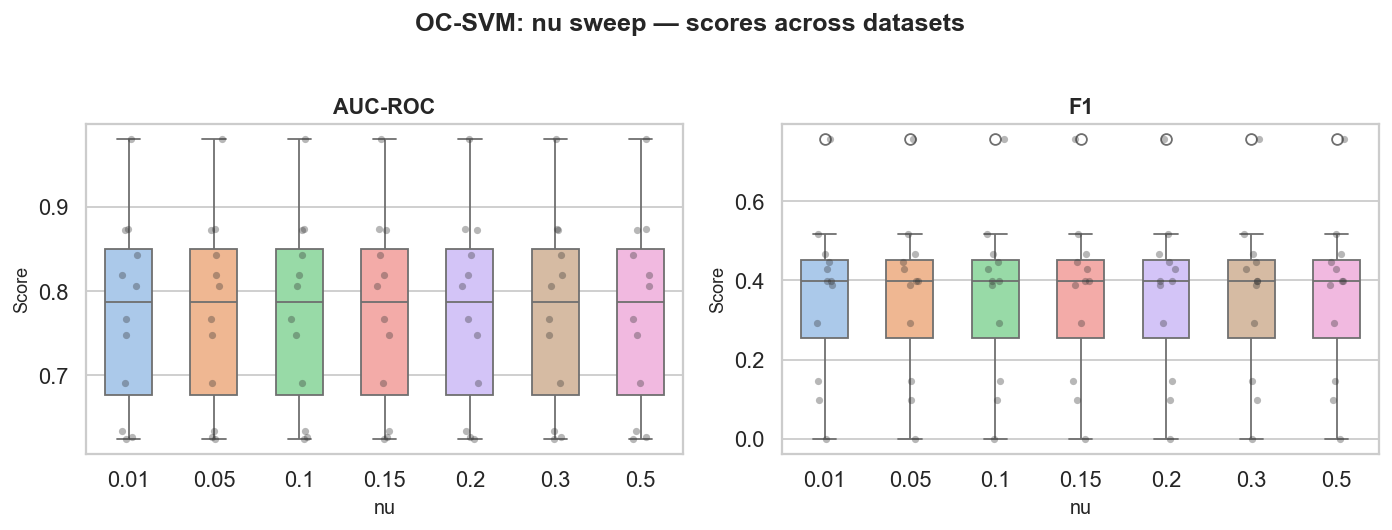

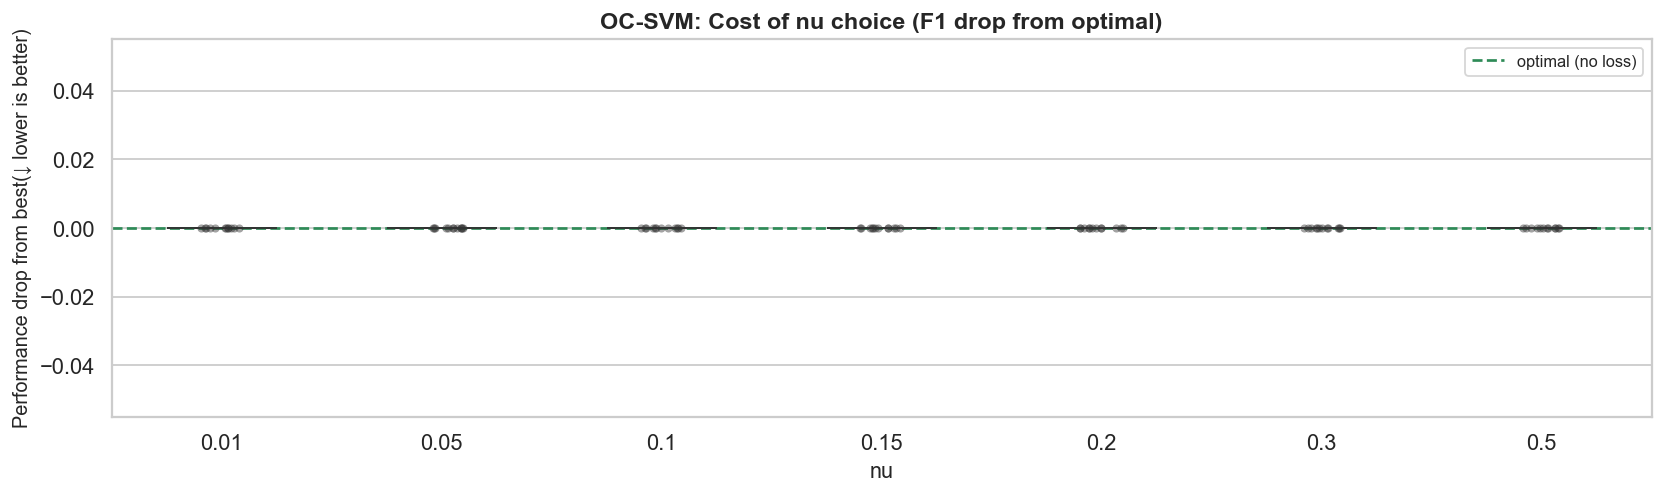

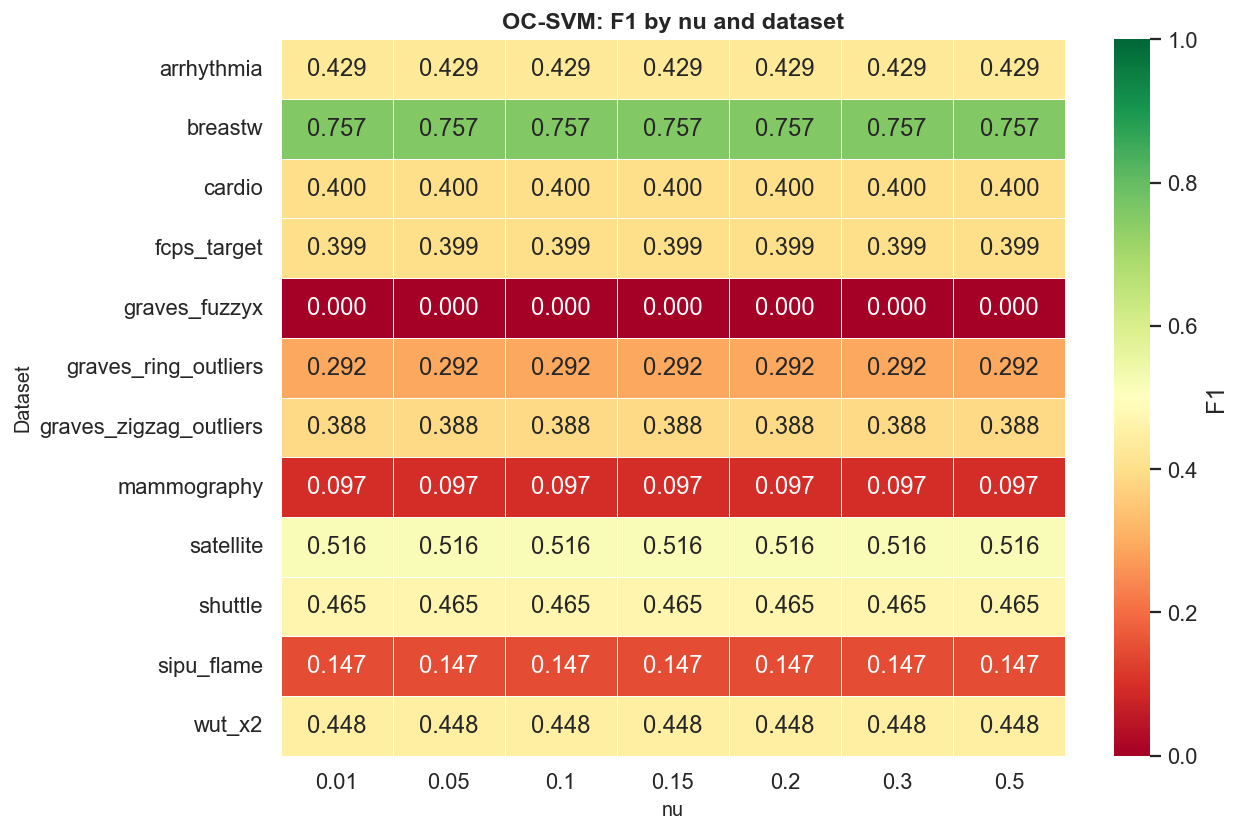

In [19]:
svm_nu = load_sweep('svm', 'nu_sweep.csv')

fig = plot_metrics_boxplots(svm_nu, param_col='nu', metrics=['auc_roc', 'f1'], title='OC-SVM: nu sweep — scores across datasets')
plt.show()
fig = plot_delta_from_best(svm_nu, 'nu', metric='f1', title='OC-SVM: Cost of nu choice (F1 drop from optimal)')
plt.show()
fig = plot_sweep_heatmap(svm_nu, param_col='nu', metric='f1', title='OC-SVM: F1 by nu and dataset')
plt.show()


Observations:

AUC-ROC is completely flat across all nu values - every boxplot looks identical. This confirms that nu does not affect anomaly scores, only where the decision boundary is placed.

surprisingly, F1 is also flat for every dataset, meaning that even the binary threshold does not shift in a meaningful way here. 

concluding from this experiment, nu can be safely ignored during tuning and can be set to be roughly equal to expected outlier rate.

### kernel sweep

The heatmap below shows which kernel wins on which dataset, making it easy to spot whether there's a universally good choice.


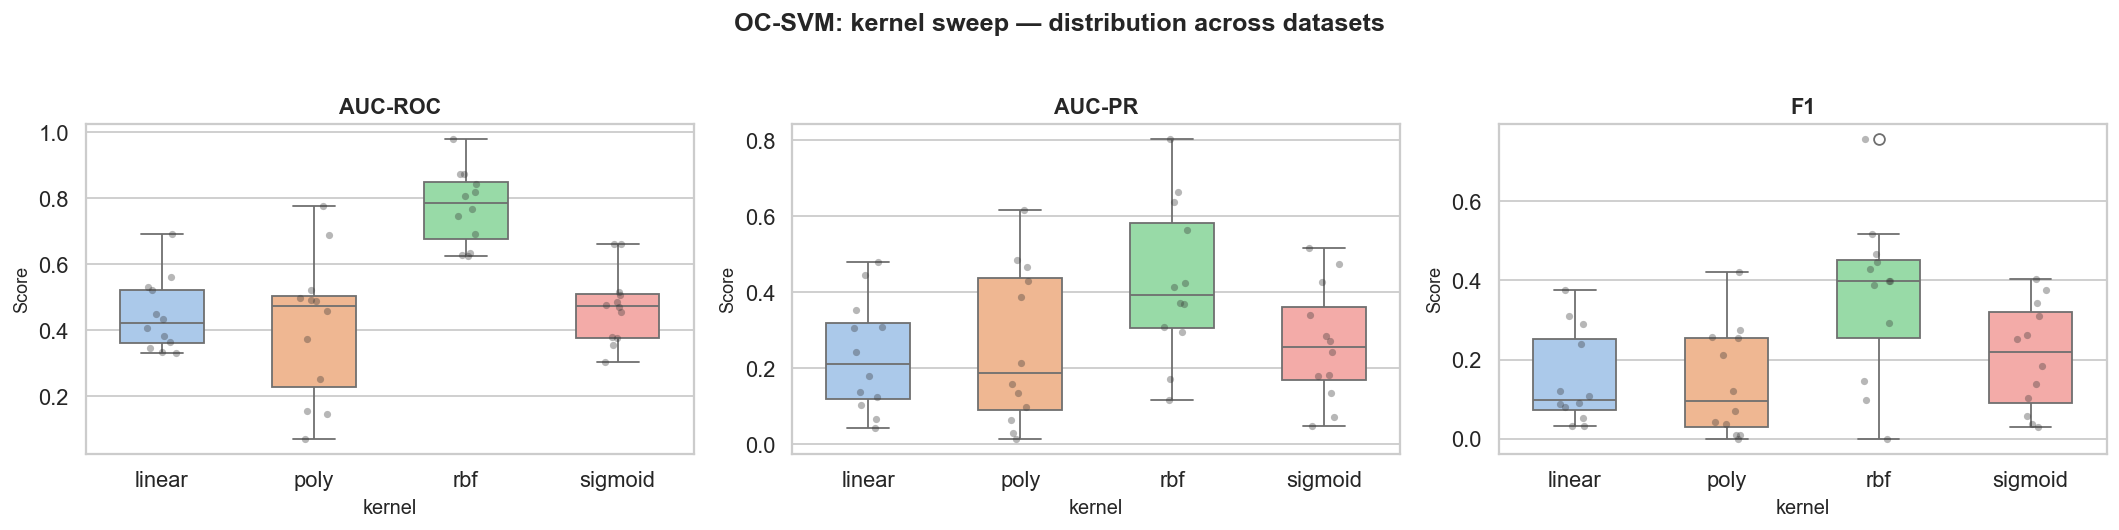

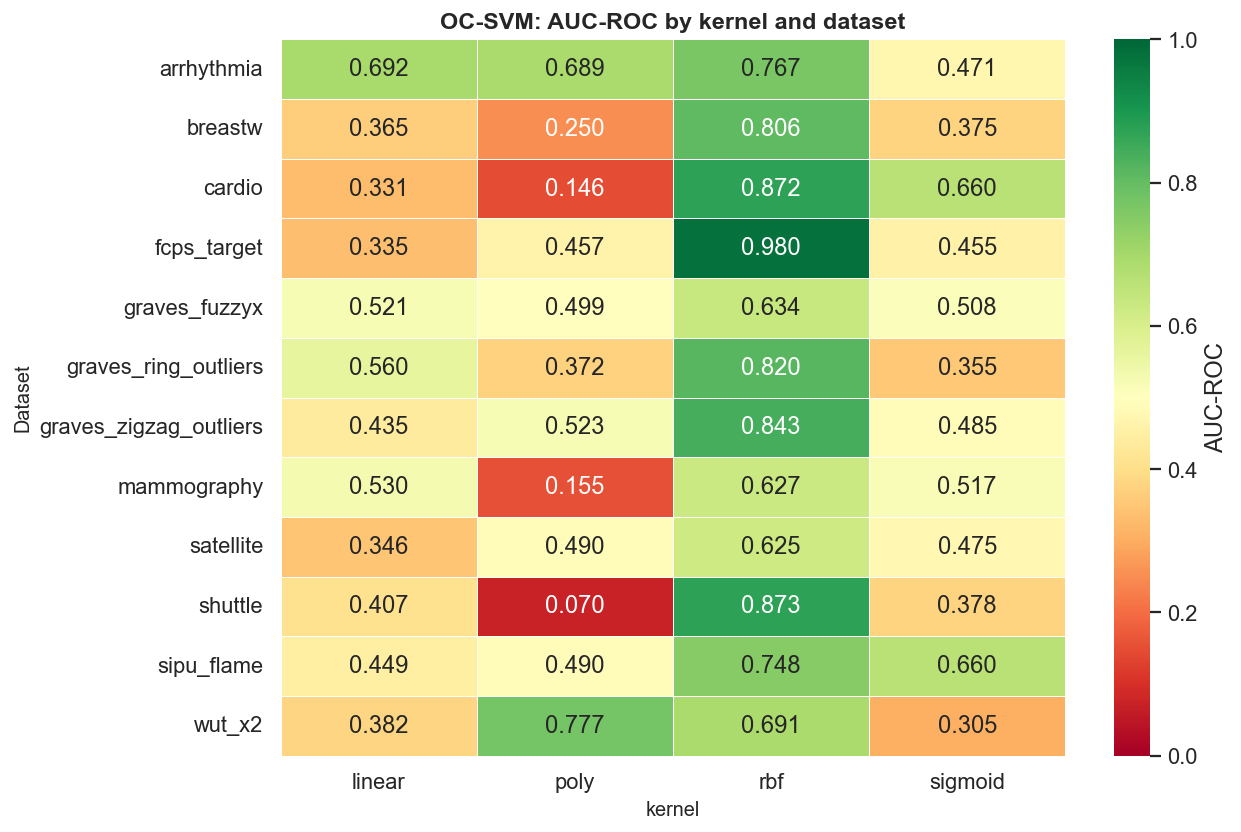


Mean metric per kernel (averaged over all datasets):


,auc_roc,auc_pr,f1
kernel,,,
rbf,0.7739,0.4281,0.3614
sigmoid,0.4704,0.2640,0.2078
linear,0.4460,0.2317,0.1509
poly,0.4098,0.2584,0.1418


In [ ]:
svm_kernel = load_sweep('svm', 'kernel_sweep.csv')

fig = plot_metrics_boxplots(svm_kernel, param_col='kernel', metrics=METRICS, title='OC-SVM: kernel sweep — distribution across datasets')
plt.show()

fig = plot_sweep_heatmap(svm_kernel, param_col='kernel', metric='auc_roc', title='OC-SVM: AUC-ROC by kernel and dataset')
plt.show()

print('\nMean metric per kernel (averaged over all datasets):')
svm_kernel.groupby('kernel')[METRICS].mean().round(4).sort_values('auc_roc', ascending=False)


Observations:

RBF kernel is the clear winner - it achieves the highest AUC-ROC on almost  every dataset (mean 0.77 vs ~0.44 for the rest). The heatmap makes this obvious: the rbf column is consistently green while poly kernel produces some dangerously low scores (e.g. 0.07 on shuttle, 0.15 on mammography). sigmoid and linear are mediocre but safe. 

Practical takeaway: use rbf - there is no reason to try other kernels first

### gamma sweep (RBF kernel only)

idea:

small gamma -> wide Gaussian -> each point influences large neighbourhood -> smooth, broad decision boundary

large gamma -> narrow Gaussian -> each point only influences its immediate neighbours -> tight, maybe fragmented boundary

also tested: scale (sets gamma that adapts to data scale), auto (heuristic based on the number of features)


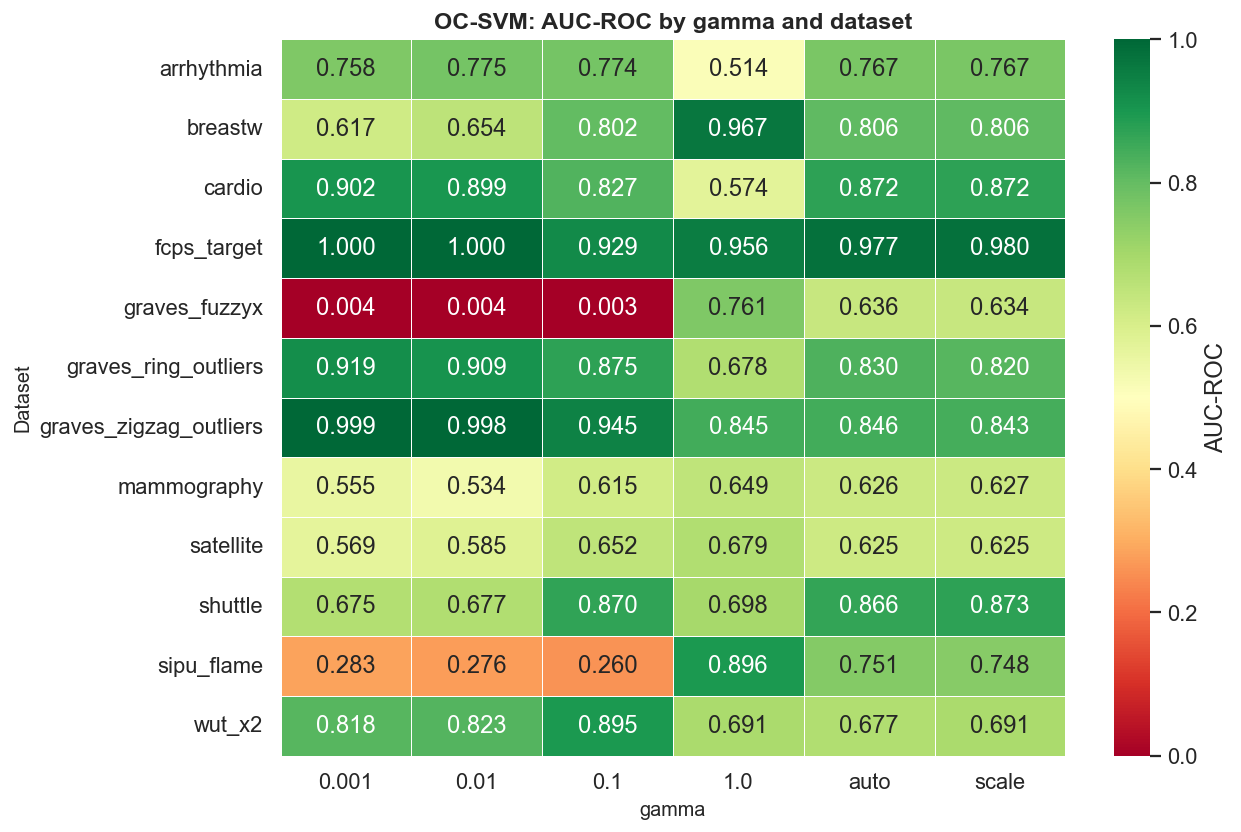

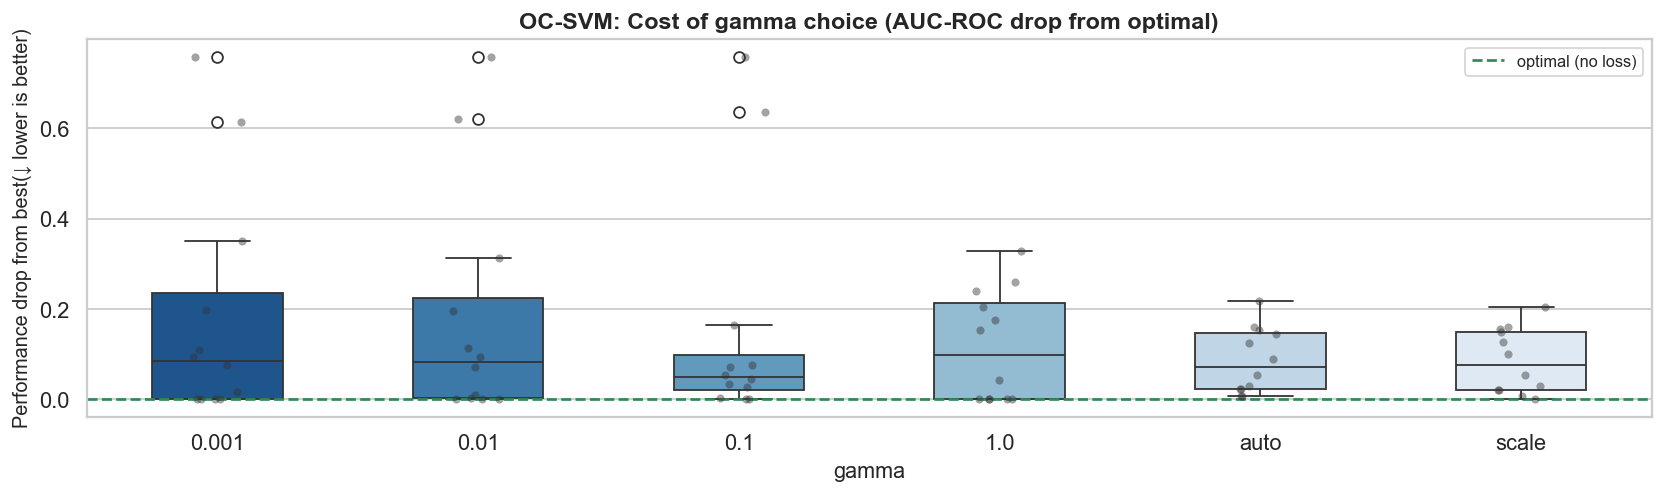

Sensitivity to gamma (AUC-ROC range per dataset):


,mean,std,range
dataset,,,
graves_fuzzyx,0.3403,0.3719,0.7585
sipu_flame,0.5355,0.2927,0.6357
breastw,0.7757,0.1258,0.3500
cardio,0.8243,0.1258,0.3290
arrhythmia,0.7257,0.1038,0.2603
graves_ring_outliers,0.8384,0.0883,0.2410
wut_x2,0.7659,0.0915,0.2182
shuttle,0.7767,0.1023,0.1982
graves_zigzag_outliers,0.9126,0.0772,0.1567


In [20]:
svm_gamma = load_sweep('svm', 'gamma_sweep.csv')
GAMMA_ORDER = ['0.001', '0.01', '0.1', '1.0', 'auto', 'scale']

fig = plot_sweep_heatmap(svm_gamma, param_col='gamma', metric='auc_roc', title='OC-SVM: AUC-ROC by gamma and dataset')
plt.show()
#how costly is a bad gamma choice?  (delta-from-best)
fig = plot_delta_from_best(svm_gamma, 'gamma', metric='auc_roc', title='OC-SVM: Cost of gamma choice (AUC-ROC drop from optimal)')
plt.show()

print('Sensitivity to gamma (AUC-ROC range per dataset):')
sensitivity_table(svm_gamma, 'gamma', 'auc_roc')


Observations:

gamma is by far the most impactful parameter for this model - a wrong value can drop AUC-ROC by up to 0.76 (graves_fuzzyx) or 0.64 (sipu_flame).

Heatmap shows there is no single gamma that wins everywhere: small values (0.001–0.01) work well for some datasets but completely fail on others (near 0.0 on graves_fuzzyx and sipu_flame).

gamma = 1.0 has the opposite problem - it's great for graves_fuzzyx but hurts cardio and graves_ring_outliers. 

The delta plot confirms that 0.1, auto, and scale have the smallest and most consistent boxes, meaning they are the safest choices without dataset-specific tuning. 

Takeaway: use gamma=scale as default as it adapts to feature variances, might be best to avoid hardcoding a fixed numeric gamma without proper validation


---
## Isolation Forest

### n_estimators sweep


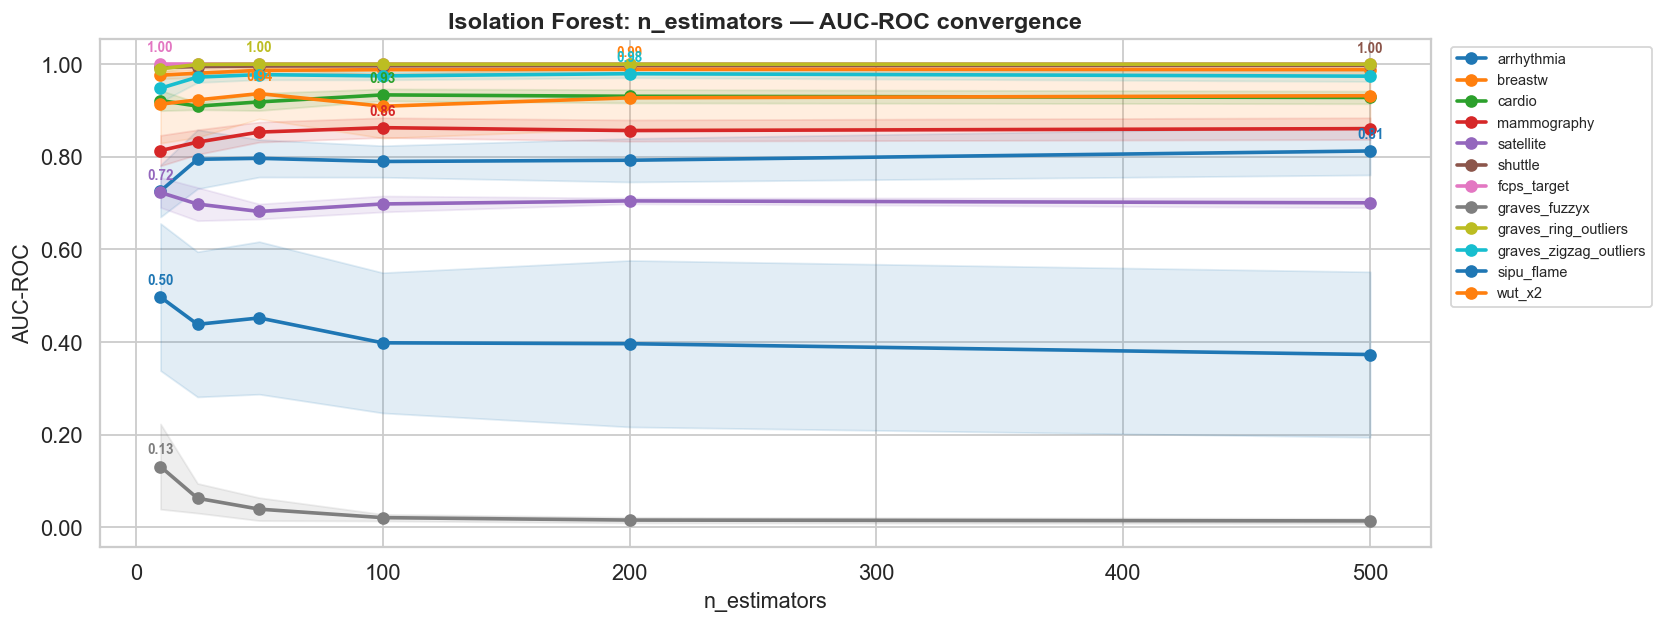

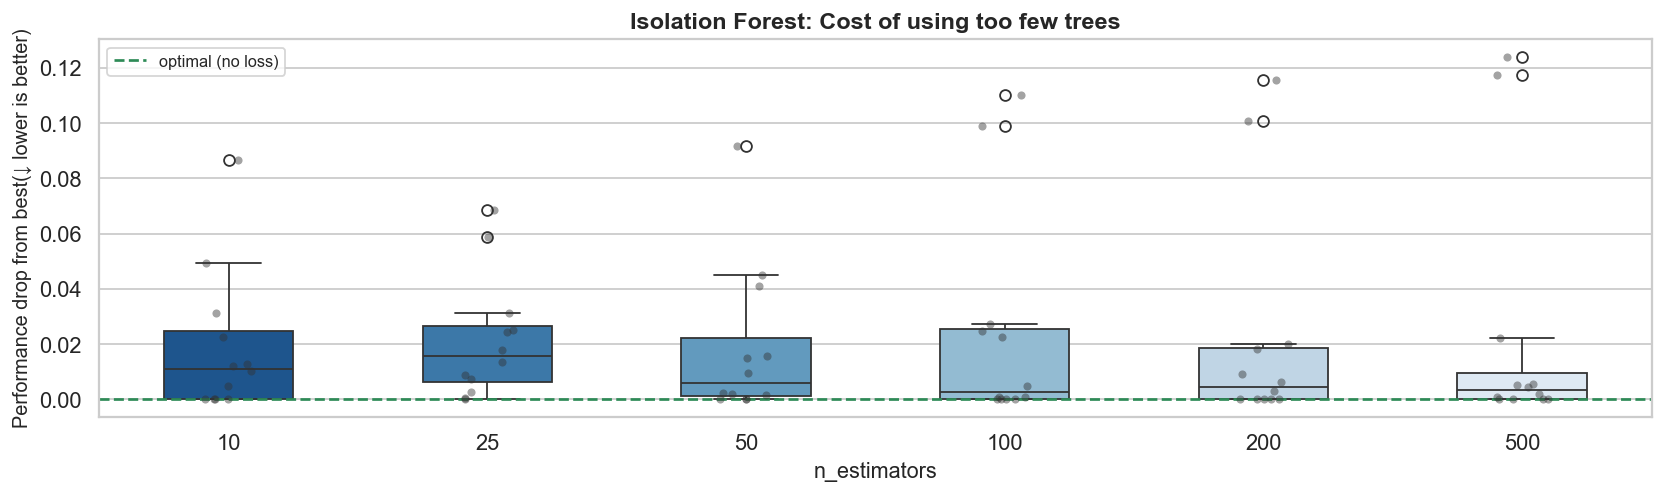

Sensitivity to n_estimators (AUC-ROC range per dataset):


,mean,std,range
dataset,,,
sipu_flame,0.4258,0.0455,0.1241
graves_fuzzyx,0.0472,0.0451,0.1173
arrhythmia,0.7853,0.0301,0.0865
mammography,0.8464,0.0197,0.0495
satellite,0.7010,0.0133,0.0410
graves_zigzag_outliers,0.9709,0.0115,0.0313
wut_x2,0.9235,0.0105,0.0273
cardio,0.9236,0.0090,0.0243
breastw,0.9847,0.0052,0.0129


In [21]:
if_nest = load_sweep('isolation_forest', 'n_estimators_sweep.csv')

fig = plot_sweep_lines(if_nest, 'n_estimators', metric='auc_roc', title='Isolation Forest: n_estimators — AUC-ROC convergence')
plt.show()
fig = plot_delta_from_best(if_nest, 'n_estimators', metric='auc_roc',  title='Isolation Forest: Cost of using too few trees')
plt.show()

print('Sensitivity to n_estimators (AUC-ROC range per dataset):')
sensitivity_table(if_nest, 'n_estimators', 'auc_roc')


Observations:

Most datasets converge very quickly - by n_estimators=50 the lines are already flat, and adding more trees beyond 100 gives virtually no improvement.

The two exceptions are sipu_flame and graves_fuzzyx which stay low regardless of tree count - this is a dataset difficulty problem, not a tuning problem. More trees won't save a bad fit.

The delta plot confirms this: median drop at n_estimators=10 is only about 0.015, meaning even a tiny forest is surprisingly competitive. The boxes don't shrink much after 50.

Takeaway: n_estimators=100 is a safe and sufficient default, going to 500 buys almost nothing

### contamination sweep

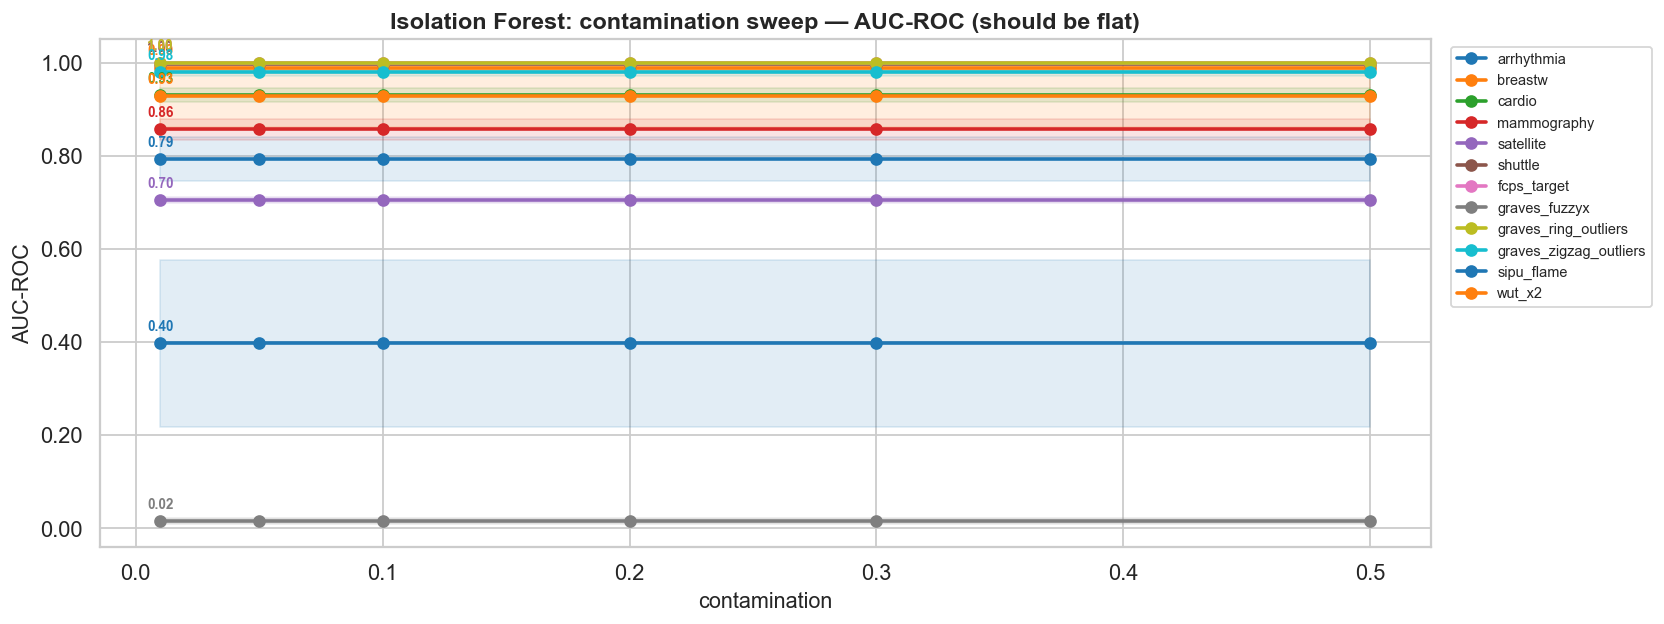

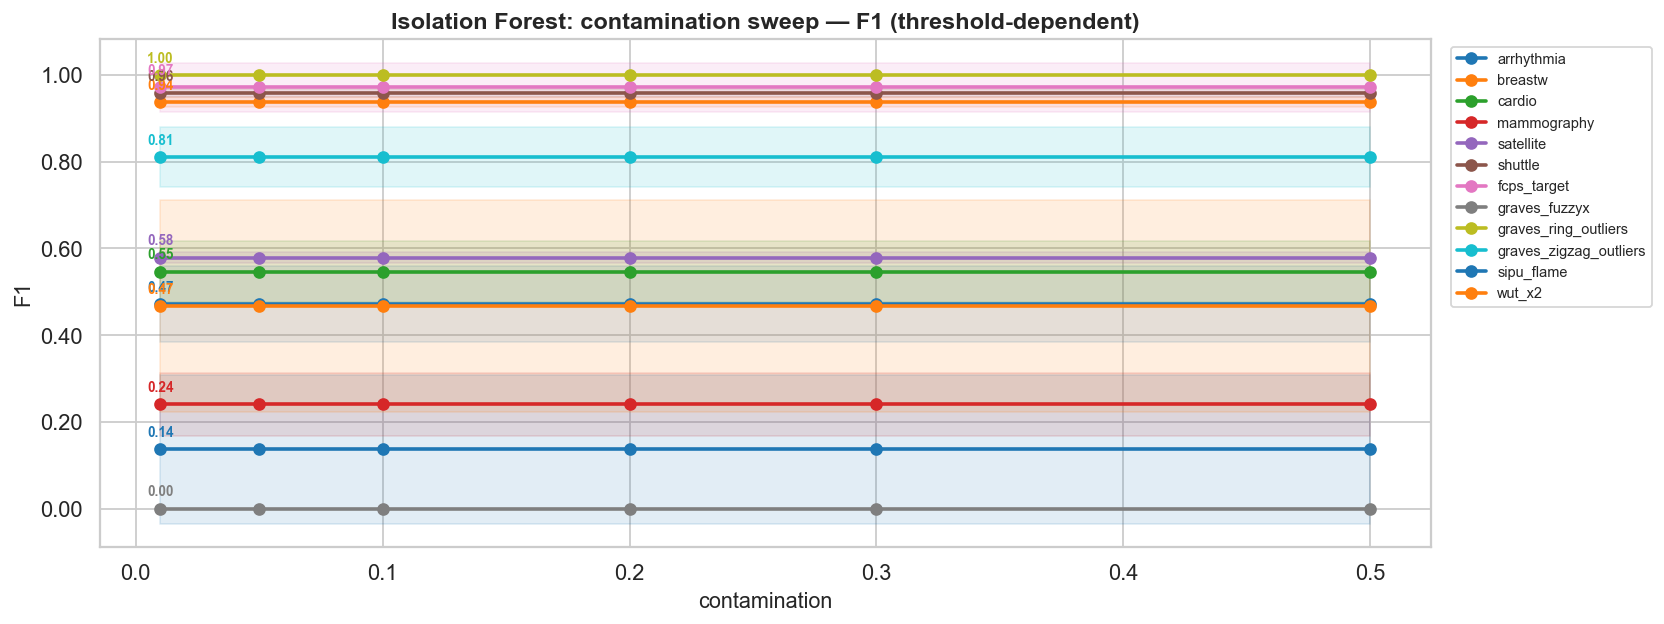

In [22]:
if_contam = load_sweep('isolation_forest', 'contamination_sweep.csv')

fig = plot_sweep_lines(if_contam, 'contamination', metric='auc_roc', title='Isolation Forest: contamination sweep — AUC-ROC (should be flat)')
plt.show()
fig = plot_sweep_lines(if_contam, 'contamination', metric='f1', title='Isolation Forest: contamination sweep — F1 (threshold-dependent)')
plt.show()


Observations:

AUC-ROC is perfectly flat across all contamination values for every dataset - confirming that anomaly scores are completely unaffected by this parameter.

F1 is also surprisingly flat - which means that even the binary threshold barely shifts across the tested contamination range on these datasets.

The wide shaded bands on both plots reflect variance across runs, not sensitivity to contamination - the lines themselves don't move.

Takeaway: contamination is a threshold-only parameter in Isolation Forest. Can be set to subjective best estimate of the true outlier rate and does not need to be tuned - for all of the datasets any value gives the same anomaly scores and nearly the same binary labels.

### max_features sweep


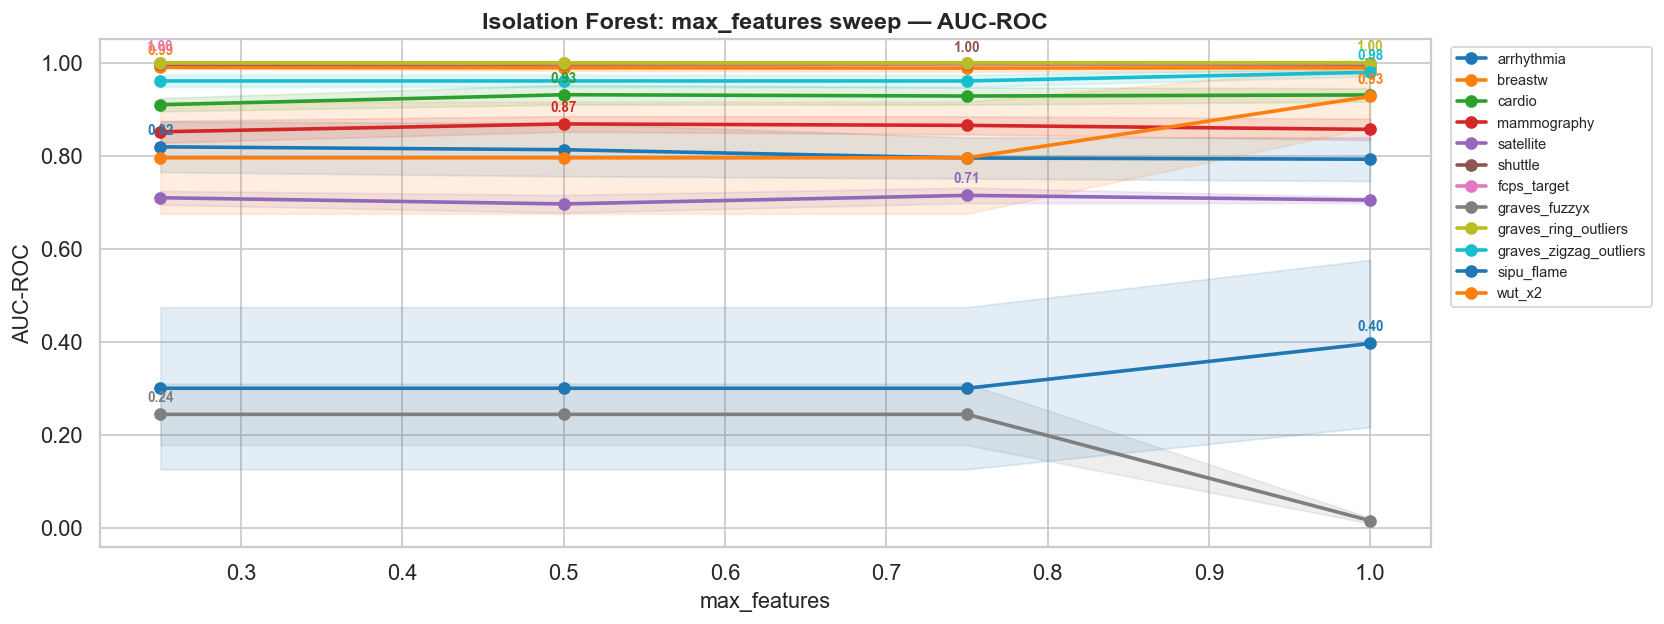

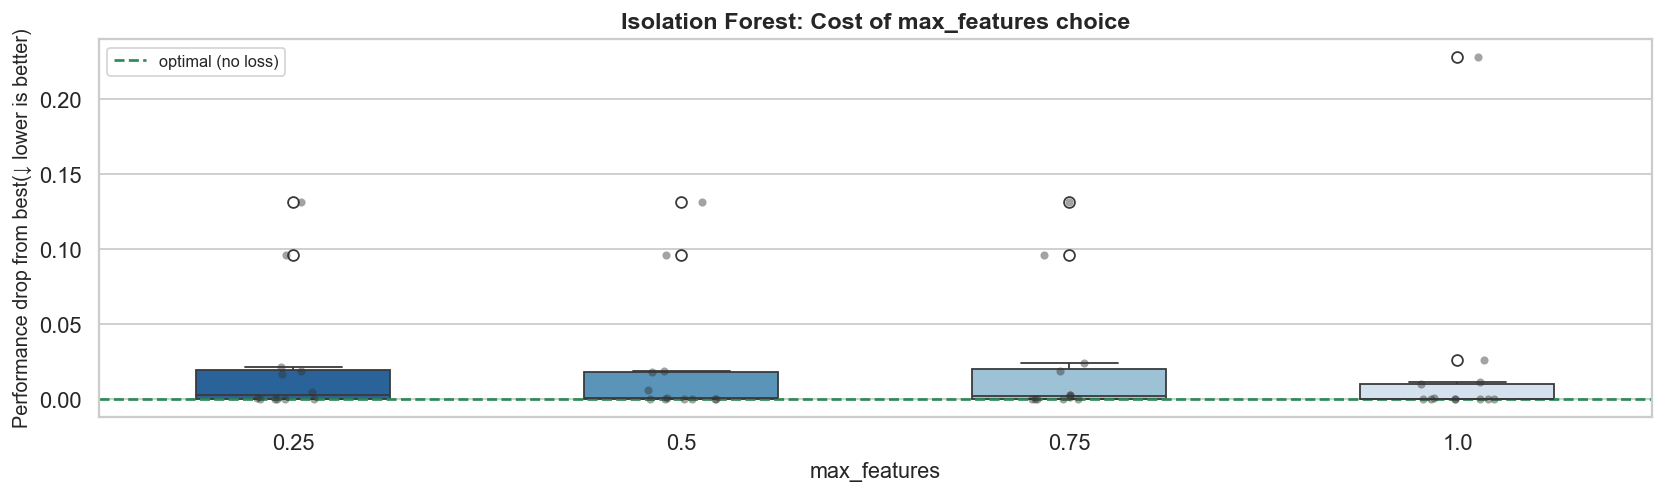

In [23]:
if_feat = load_sweep('isolation_forest', 'max_features_sweep.csv')

fig = plot_sweep_lines(if_feat, 'max_features', metric='auc_roc', title='Isolation Forest: max_features sweep — AUC-ROC')
plt.show()
fig = plot_delta_from_best(if_feat, 'max_features', metric='auc_roc', title='Isolation Forest: Cost of max_features choice')
plt.show()


Observations:

Most datasets are completely flat across all max_features values - the lines barely move, confirming that this parameter has negligible effect in the majority of cases.

Two exceptions: graves_fuzzyx drops sharply at max_features=1.0 (from ~0.25 to near 0), and sipu_flame actually improves at 1.0. These are outliers, not a general trend.

The delta plot confirms this - median boxes are tiny and close to zero for all values, with only a handful of outlier points pulling the whiskers up.

Takeaway: max_features is safe to leave at the default (1.0) for most datasets. It is probably not worth to include this parameter in the grid search unless mayble one believes that its data is noisy or has irrelevant features. 

---
## Local Outlier Factor (LOF)

### n_neighbors sweep

probably no single default since the optimal k is strongly dependent on the dataset itself


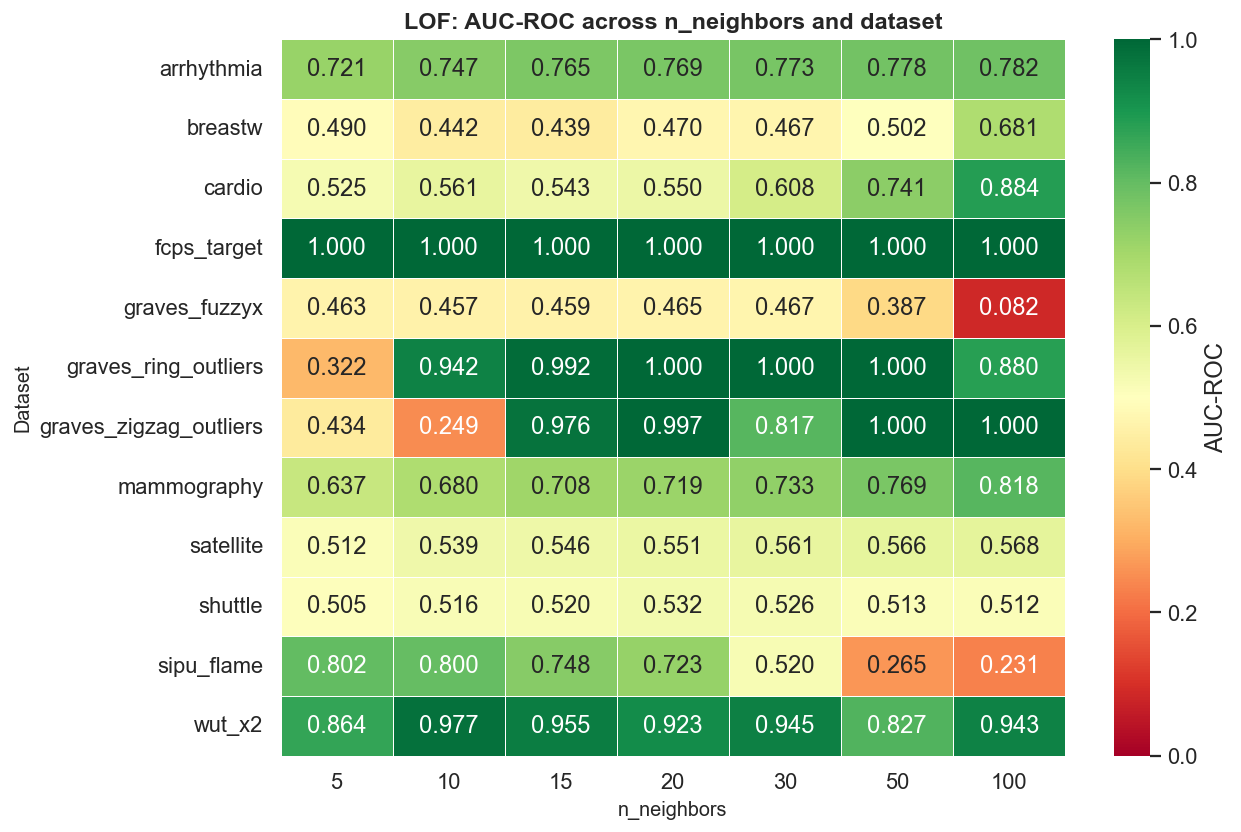

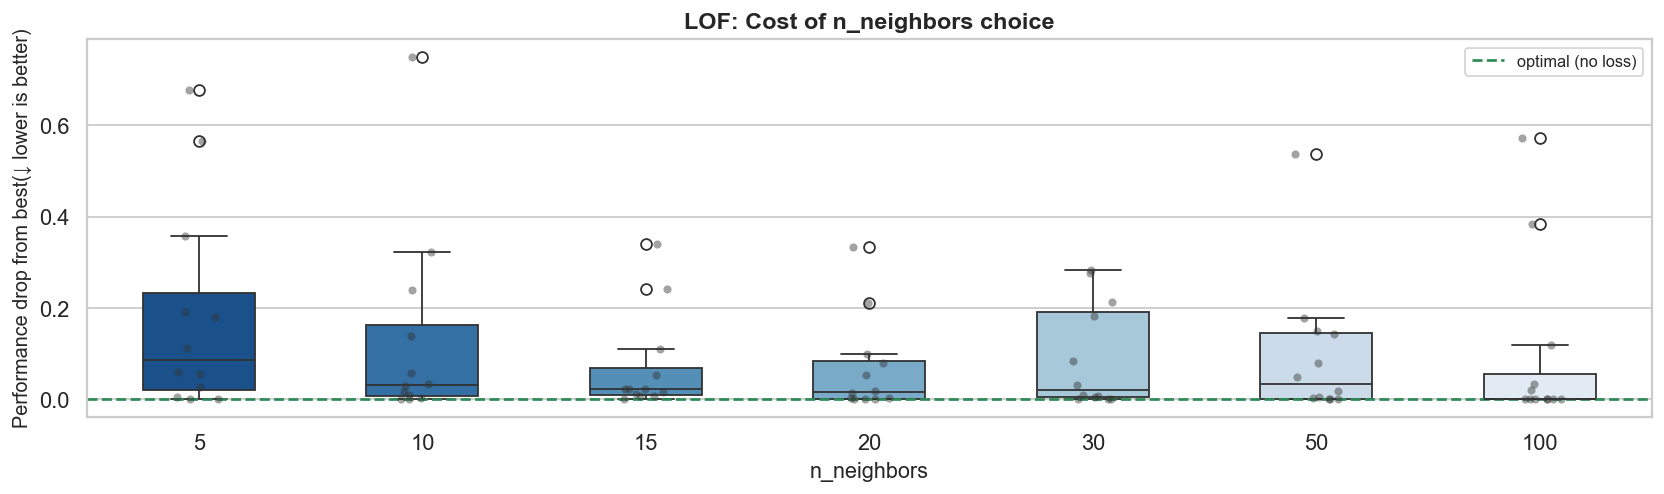

Sensitivity to n_neighbors (AUC-ROC range per dataset):


,mean,std,range
dataset,,,
graves_zigzag_outliers,0.7819,0.3122,0.7507
graves_ring_outliers,0.8764,0.2486,0.6780
sipu_flame,0.5841,0.2487,0.5715
graves_fuzzyx,0.3972,0.1417,0.3849
cardio,0.6303,0.1335,0.3586
breastw,0.4987,0.0837,0.2423
mammography,0.7234,0.0589,0.1816
wut_x2,0.9192,0.0539,0.1500
arrhythmia,0.7619,0.0212,0.0609


In [24]:
lof_k = load_sweep('local_outlier_factor', 'n_neighbors_sweep.csv')

fig = plot_sweep_heatmap(lof_k, param_col='n_neighbors', metric='auc_roc', title='LOF: AUC-ROC across n_neighbors and dataset')
plt.show()
fig = plot_delta_from_best(lof_k, 'n_neighbors', metric='auc_roc', title='LOF: Cost of n_neighbors choice')
plt.show()

print('Sensitivity to n_neighbors (AUC-ROC range per dataset):')
sensitivity_table(lof_k, 'n_neighbors', 'auc_roc')


Observations:

n_neighbors is the most dataset-dependent parameter we've seen so far - the heatmap shows completely opposite preferences: sipu_flame peaks at k=5 (0.80) and collapses at k=100 (0.23), while cardio and breastw do the opposite, improving steadily as k grows.

The most extreme cases are graves_ring_outliers and graves_zigzag_outliers - both start low at k=5 (~0.32 and 0.43) and jump to near-perfect at k=15–20, then drop again at k=100. 

graves_fuzzyx is the opposite extreme - it's already weak everywhere and falls off at k=100 (0.08), suggesting LOF simply doesn't suit the structure of that dataset.

As suspected, the delta plot has no obvious winner - boxes are large and scattered at both ends (k=5 and k=100), with k=15–20 showing the smallest median drop overall.

Takeaway: always sweep n_neighbors for LOF - there is no safe universal default. 

### metric sweep


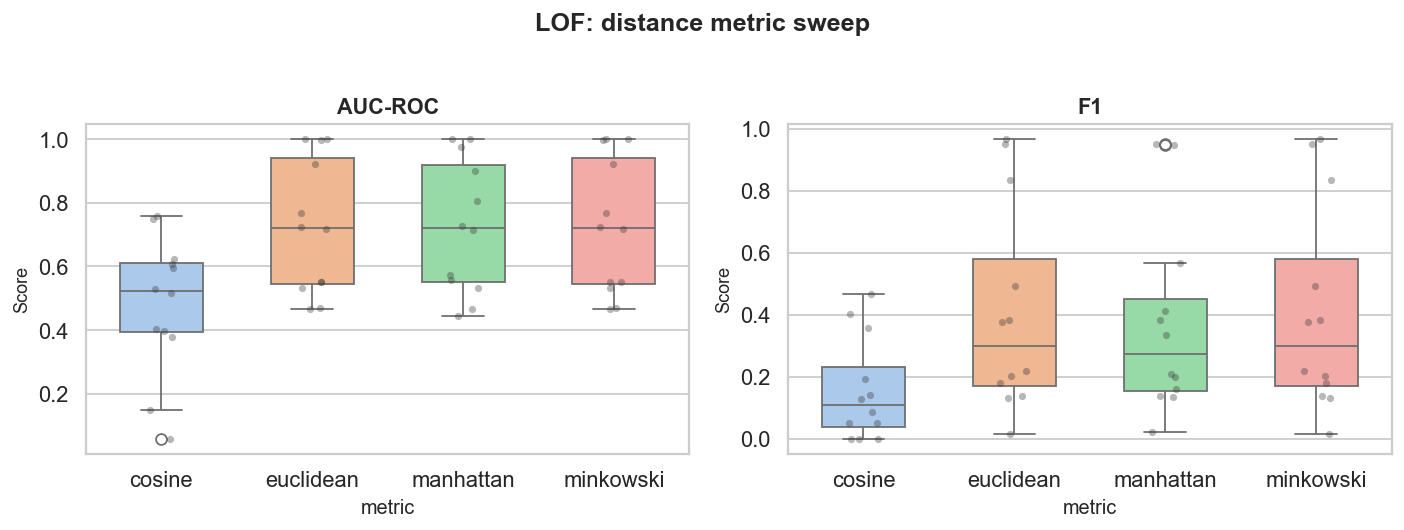

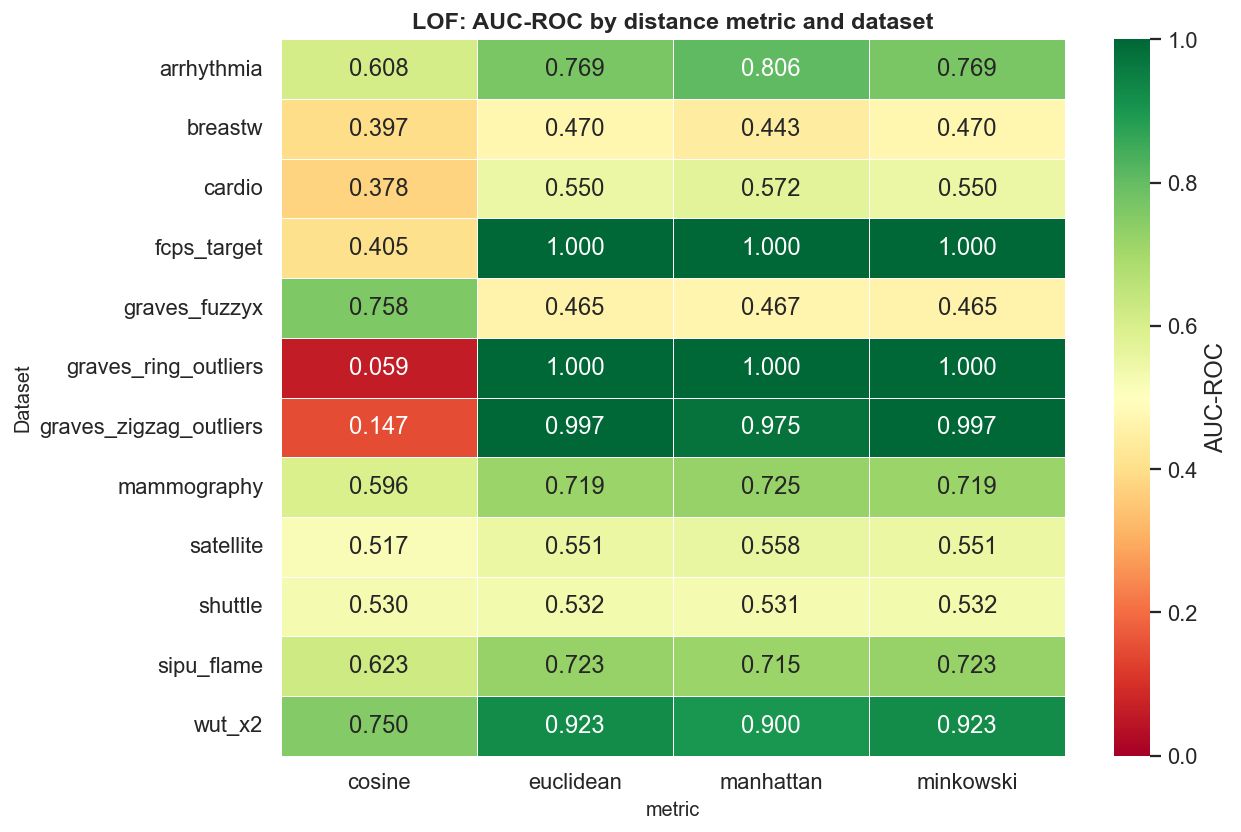


Mean metric per distance metric:


,auc_roc,auc_pr,f1
metric,,,
euclidean,0.7248,0.4596,0.4072
minkowski,0.7248,0.4596,0.4072
manhattan,0.7244,0.4489,0.3715
cosine,0.4807,0.1993,0.1563


In [25]:
lof_metric = load_sweep('local_outlier_factor', 'metric_sweep.csv')

fig = plot_metrics_boxplots(lof_metric, param_col='metric', metrics=['auc_roc', 'f1'], title='LOF: distance metric sweep')
plt.show()
fig = plot_sweep_heatmap(lof_metric, param_col='metric', metric='auc_roc', title='LOF: AUC-ROC by distance metric and dataset')
plt.show()

print('\nMean metric per distance metric:')
lof_metric.groupby('metric')[METRICS].mean().round(4).sort_values('auc_roc', ascending=False)


Observations:

Cosine is a clear outlier - it catastrophically fails on graves_ring_outliers (0.06) and graves_zigzag_outliers (0.15) where all other metrics hit near-perfect 1.0.

Euclidean, manhattan, and minkowski are virtually identical across all datasets - not worth sweeping separately.

Takeaway: stick with euclidean, avoid cosine unless data is sparse or high-dimensional.

### contamination sweep

Like OC-SVM, LOF scores are independent of contamination - only the binary threshold changes. AUC-based metrics are completely flat.


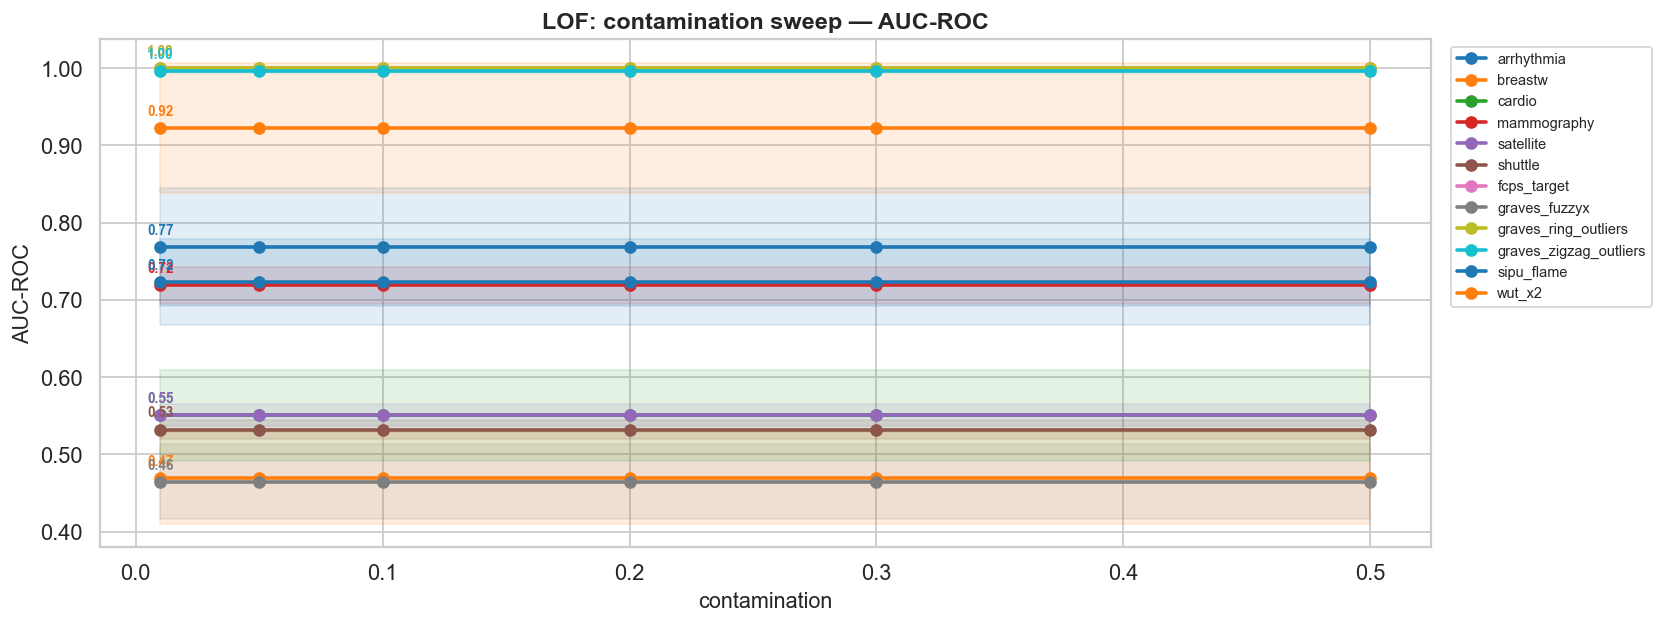

In [27]:
lof_contam = load_sweep('local_outlier_factor', 'contamination_sweep.csv')

fig = plot_sweep_lines(lof_contam, 'contamination', metric='auc_roc', title='LOF: contamination sweep — AUC-ROC')
plt.show()


---
## DBSCAN

### eps sweep  (min_samples = 5 fixed)

In the sweep below, eps_fraction is a multiplier on the heuristic auto-eps, so 1.0 = the elbow value.

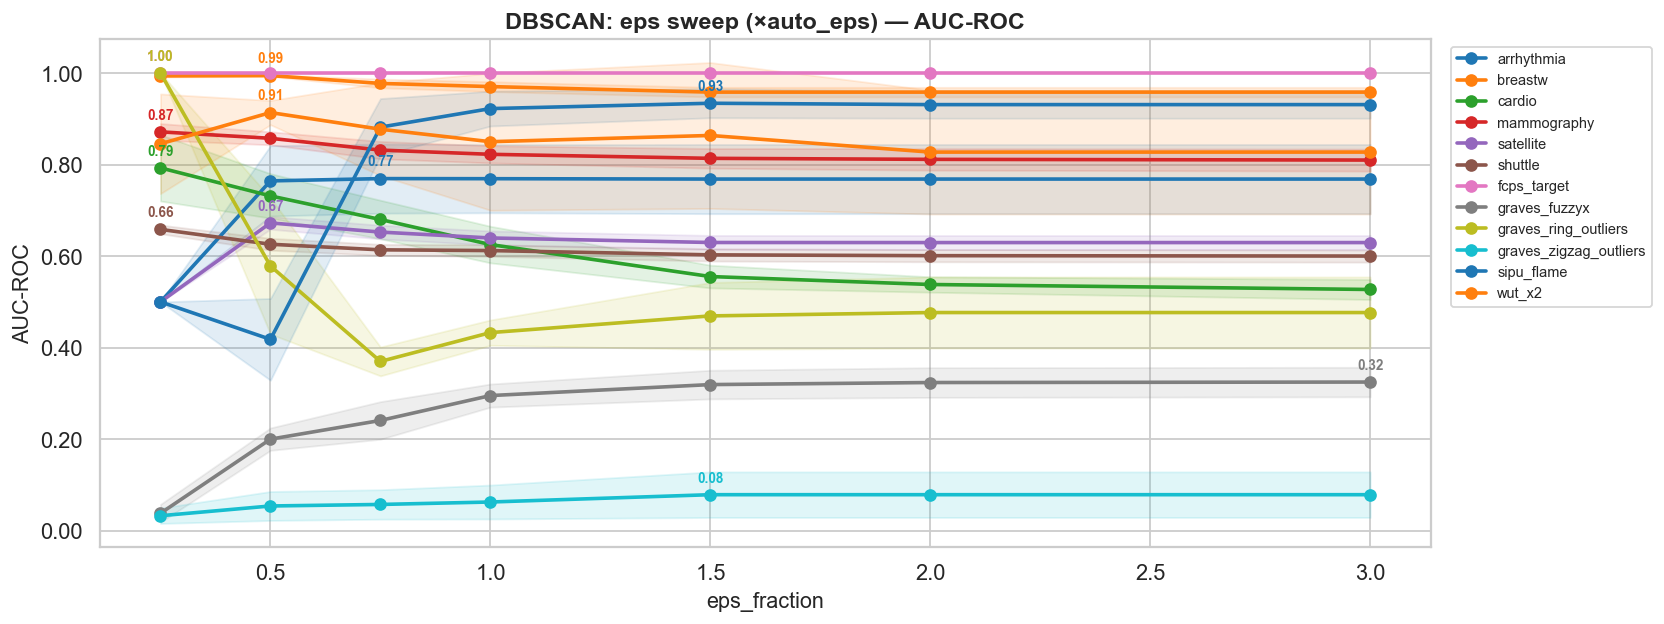

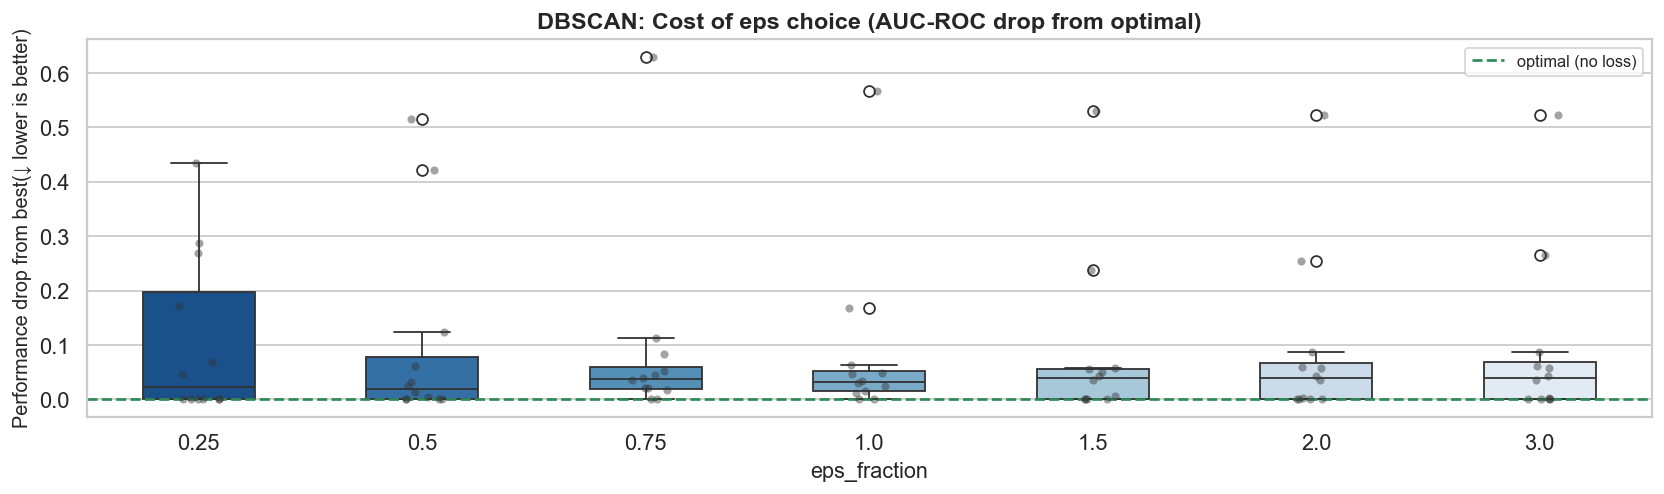

Sensitivity to eps (AUC-ROC range per dataset):


,mean,std,range
dataset,,,
graves_ring_outliers,0.5434,0.2107,0.6302
sipu_flame,0.7883,0.2269,0.5159
graves_fuzzyx,0.2489,0.1044,0.2868
arrhythmia,0.7297,0.1013,0.2694
cardio,0.6357,0.1031,0.2657
satellite,0.6220,0.0561,0.1726
wut_x2,0.8578,0.0306,0.0864
mammography,0.8311,0.0243,0.0616
shuttle,0.6163,0.0207,0.0583


In [28]:
db_eps = load_sweep('dbscan', 'eps_sweep.csv')

fig = plot_sweep_lines(db_eps, 'eps_fraction', metric='auc_roc', title='DBSCAN: eps sweep (×auto_eps) — AUC-ROC')
plt.show()
fig = plot_delta_from_best(db_eps, 'eps_fraction', metric='auc_roc', title='DBSCAN: Cost of eps choice (AUC-ROC drop from optimal)')
plt.show()

print('Sensitivity to eps (AUC-ROC range per dataset):')
sensitivity_table(db_eps, 'eps_fraction', 'auc_roc')


Observations:

eps is highly impactful - graves_ring_outliers swings by 0.63 and sipu_flame by 0.52 across the tested range, while some datasets (fcps_target, breastw) are barely affected.


Very small eps (0.25×auto) is the riskiest choice - the delta plot shows the largest and most spread boxes there, meaning many datasets are far from their optimum.

Beyond eps=0.75×auto the lines mostly stabilise, suggesting the heuristic auto_eps is a reasonable choice and slight upward scaling (0.75–1.0×) is generally safe.

Takeaway: probably do not go for less then 0.5×auto_eps. Best start at 1.0×auto and do a small sweep around [0.5, 0.75, 1.0, 1.5] - going higher than that rarely helps.

### min_samples sweep  (eps = auto fixed)


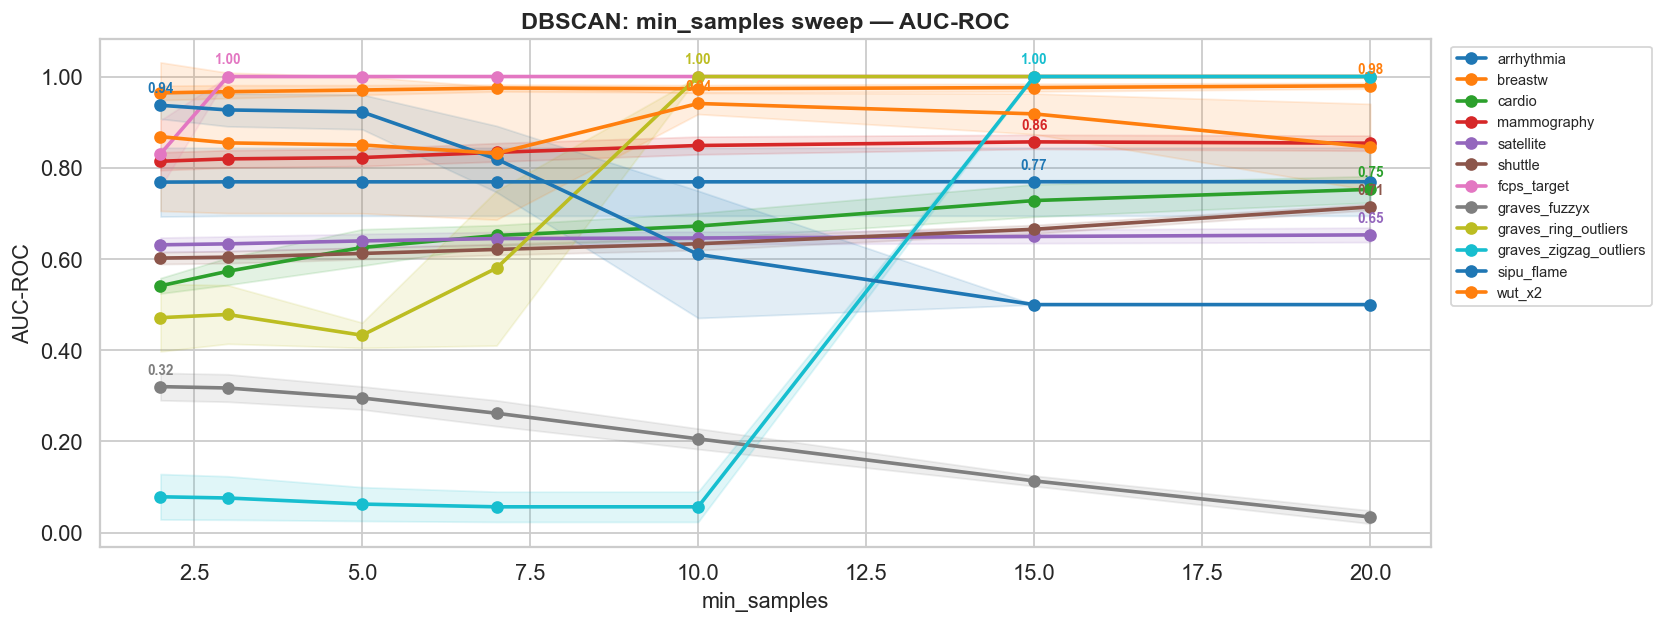

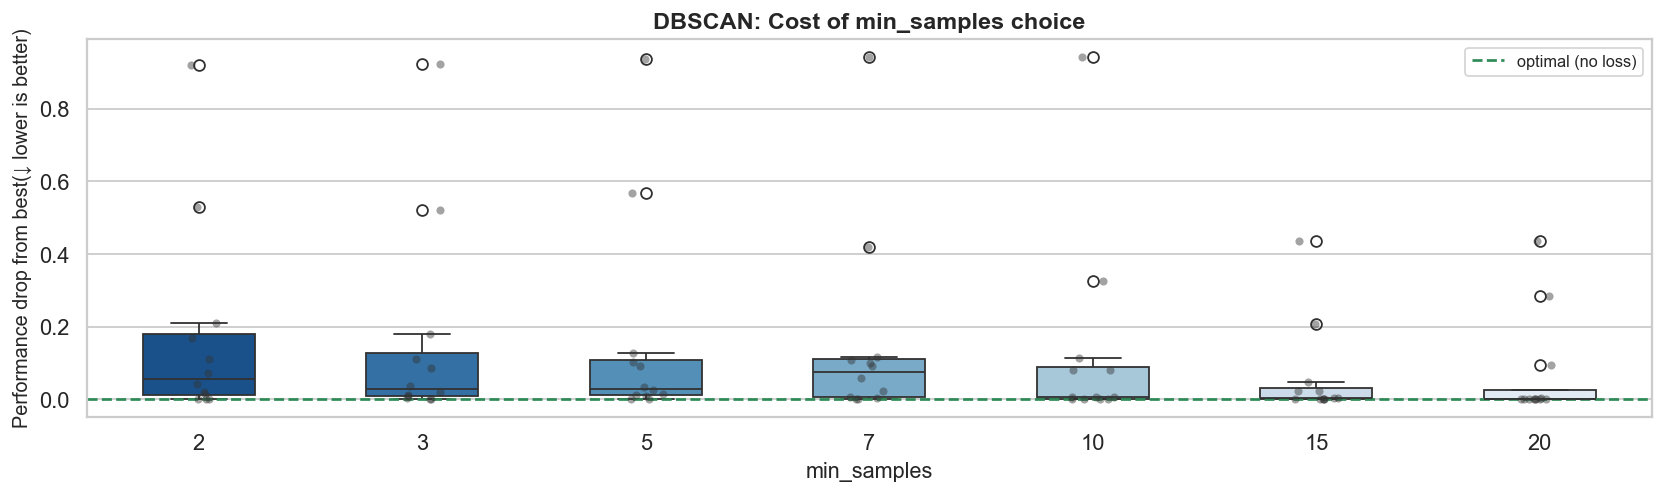

In [29]:
db_ms = load_sweep('dbscan', 'minsamples_sweep.csv')

fig = plot_sweep_lines(db_ms, 'min_samples', metric='auc_roc', title='DBSCAN: min_samples sweep — AUC-ROC')
plt.show()
fig = plot_delta_from_best(db_ms, 'min_samples', metric='auc_roc', title='DBSCAN: Cost of min_samples choice')
plt.show()


Observations:

No single value wins everywhere - graves_zigzag_outliers peaks at 15 while graves_fuzzyx collapses at the same value. The lines actively cross each other.

Small values (2–3) are consistently suboptimal; large values (15–20) have the smallest median drop but produce the worst outlier failures.

Takeaway: min_samples=5 is the safest default, but always tune it together with eps - these two parameters interact too strongly to sweep independently.

### eps x min_samples 2D heatmap

The heatmap shows how the two main DBSCAN parameters interact per dataset.
A single bad choice along either axis can cause complete failure which is the core challenge of using DBSCAN for anomaly detection.

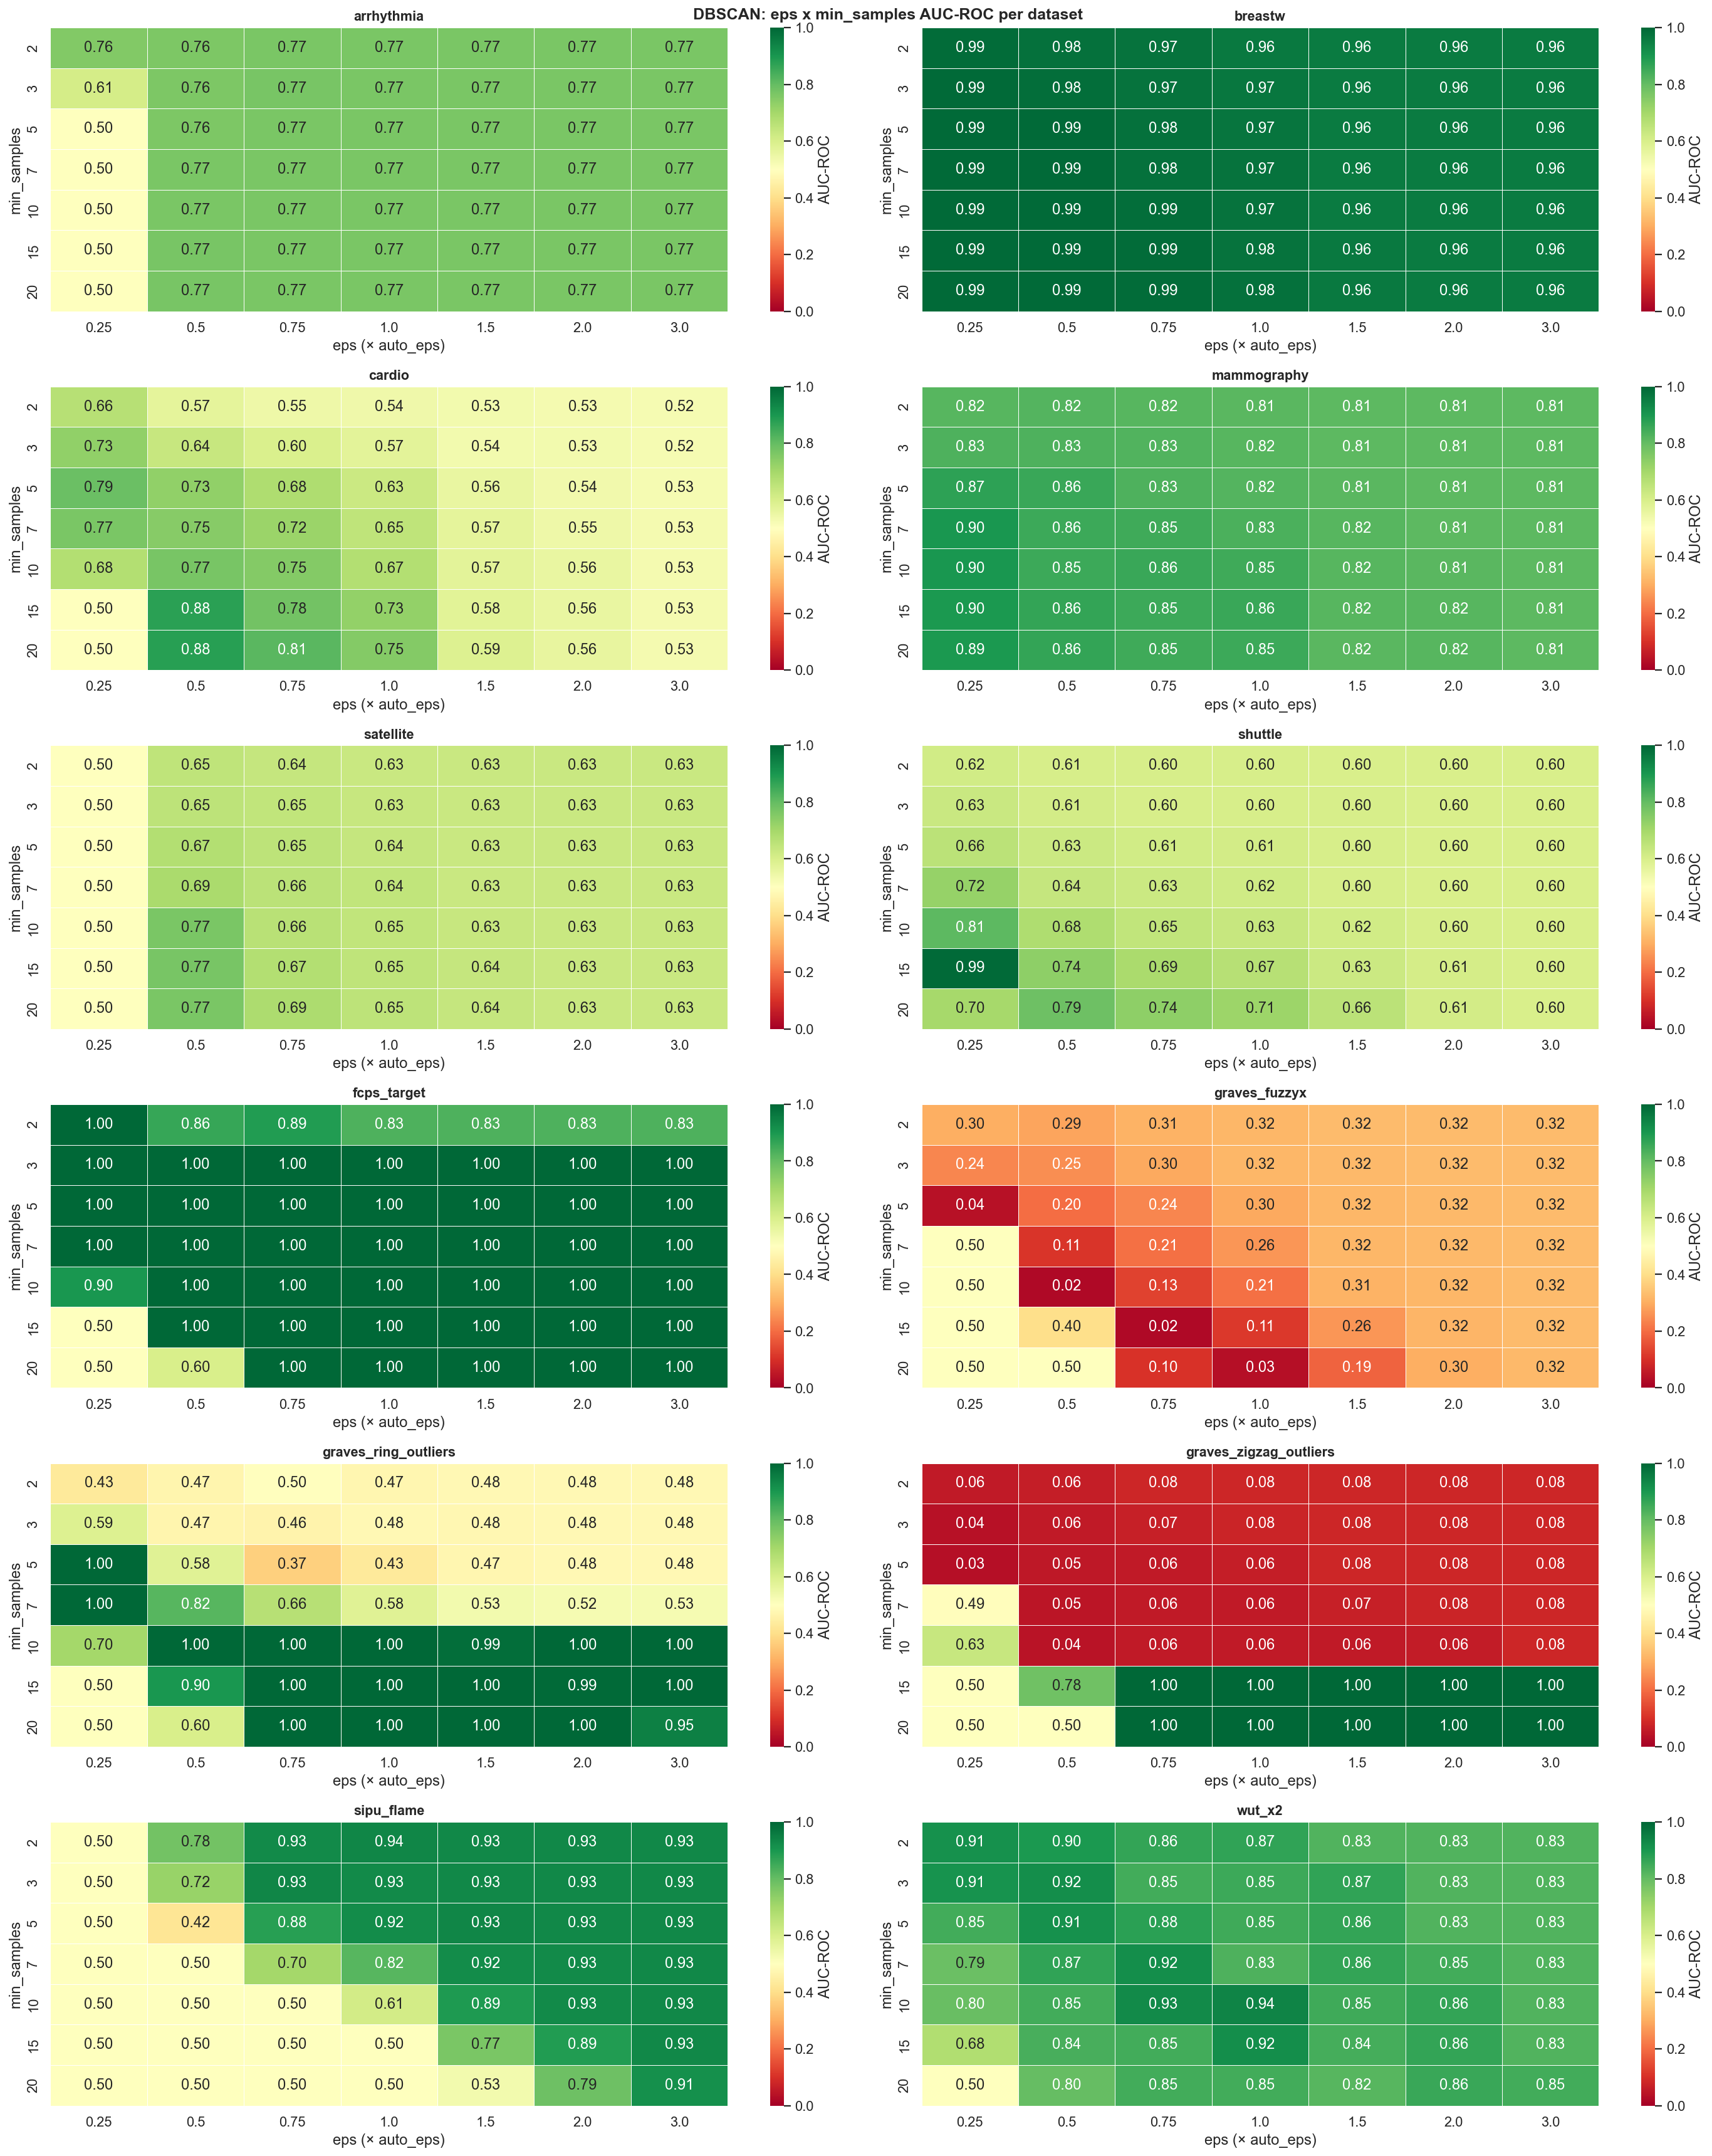

In [32]:
db_grid = load_sweep('dbscan', 'eps_x_minsamples_grid.csv')

datasets = db_grid['dataset'].unique()
n = len(datasets)
ncols = 2
nrows = (n + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 4.5))
axes = axes.flatten()

for i, ds in enumerate(datasets):
    sub = db_grid[db_grid['dataset'] == ds]
    pivot = sub.pivot_table(index='min_samples', columns='eps_fraction', values='auc_roc')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.3, cbar_kws={'label': 'AUC-ROC'}, vmin=0, vmax=1, ax=axes[i])
    axes[i].set_title(f'{ds}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('eps (× auto_eps)')
    axes[i].set_ylabel('min_samples')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('DBSCAN: eps x min_samples AUC-ROC per dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Observations:

Every dataset has a completely different "green zone" - there is no (eps, min_samples) pair that works well universally across all grids.

Some datasets are forgiving (breastw, fcps_target - almost entirely green), while others have a tiny optimal region (graves_zigzag_outliers - only the bottom two rows hit 1.0, everything else is near 0).

Takeaway: always run the 2D grid per dataset. A single default pair will be suboptimal for most and catastrophic for some.

---
## ECOD Parameter-Free Baseline

ECOD (Empirical Cumulative distribution-based Outlier Detection) estimates outlier scores purely from empirical CDFs - it has no structural hyperparameters. contamination only moves the threshold; anomaly scores are fixed.

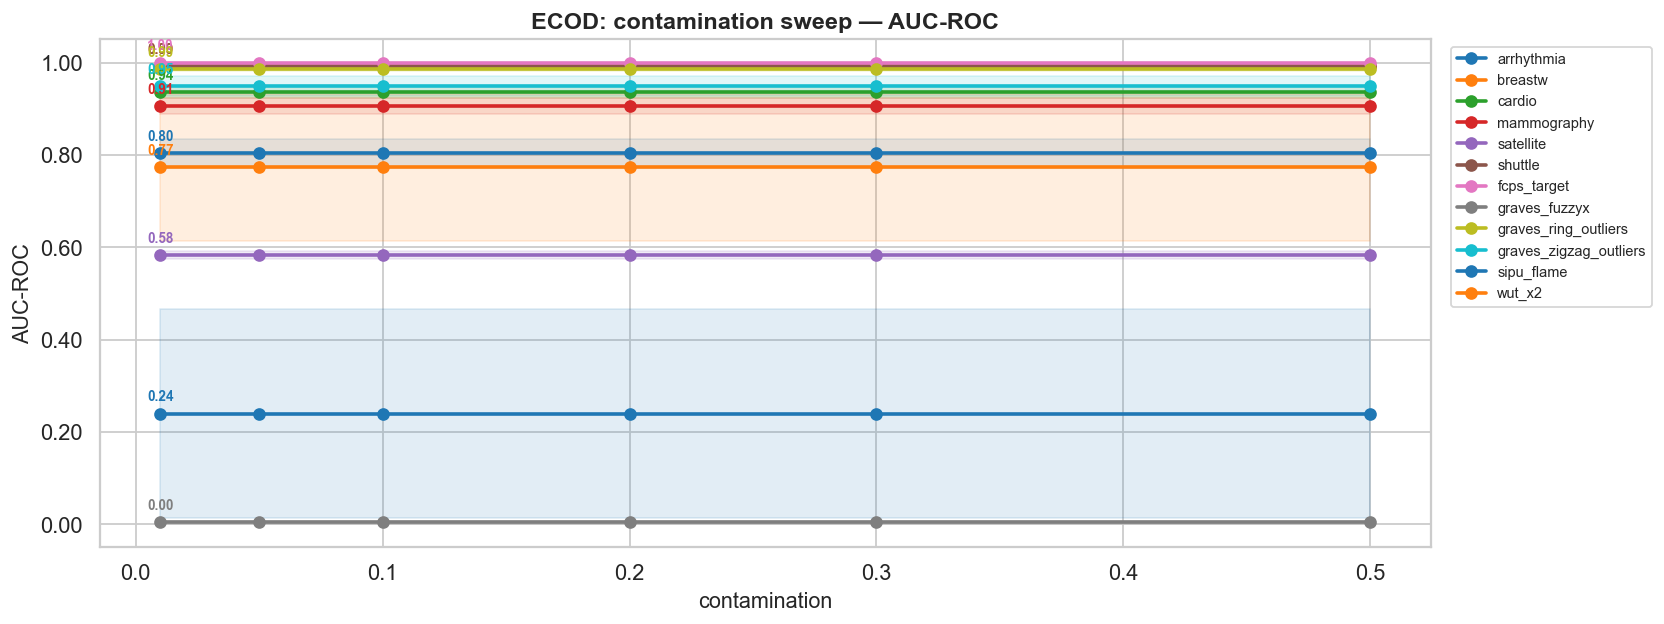

ECOD AUC-ROC std per dataset (should be ~0):


dataset
arrhythmia                0.0
breastw                   0.0
cardio                    0.0
fcps_target               0.0
graves_fuzzyx             0.0
graves_ring_outliers      0.0
graves_zigzag_outliers    0.0
mammography               0.0
satellite                 0.0
shuttle                   0.0
sipu_flame                0.0
wut_x2                    0.0
Name: auc_roc, dtype: float64

In [34]:
ecod = load_sweep('ecod', 'contamination_sweep.csv')

fig = plot_sweep_lines(ecod, 'contamination', metric='auc_roc', title='ECOD: contamination sweep — AUC-ROC')
plt.show()
print('ECOD AUC-ROC std per dataset (should be ~0):')
ecod.groupby('dataset')['auc_roc'].std().round(6)


ECOD scores are fully parameter-free. Setting contamination to be close to estimated outlier rate is the only tuning required, and it only affects binary labels.

---
## Stability Summary

### Mean AUC-ROC range per parameter sweep
Higher range = more sensitive to the parameter. Bars are coloured green / amber / red.

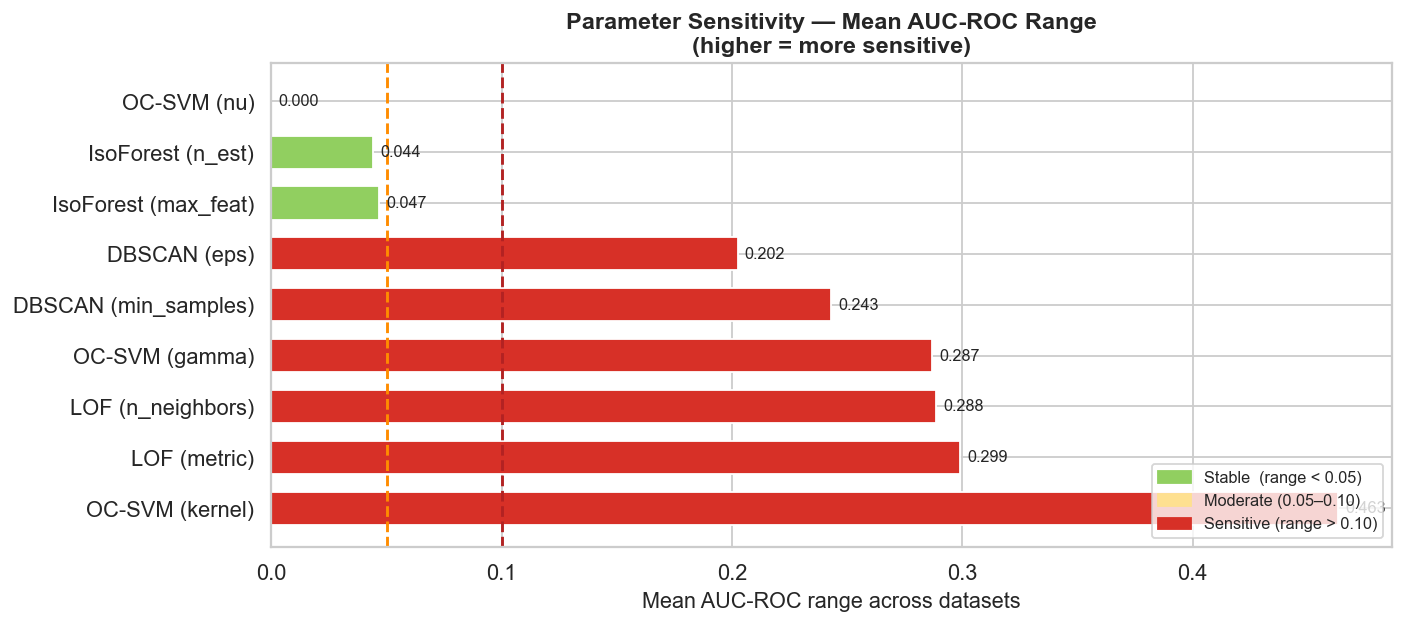

,Algorithm,Parameter,Mean AUC-ROC,Mean range,Mean std
1,OC-SVM (kernel),kernel,0.5250,0.4632,0.2062
6,LOF (metric),metric,0.6637,0.2991,0.1469
5,LOF (n_neighbors),n_neighbors,0.6867,0.2885,0.1109
2,OC-SVM (gamma),gamma,0.7244,0.2870,0.1244
8,DBSCAN (min_samples),min_samples,0.6967,0.2430,0.1082
7,DBSCAN (eps),eps_fraction,0.6591,0.2024,0.0760
4,IsoForest (max_feat),max_features,0.7990,0.0468,0.0232
3,IsoForest (n_est),n_estimators,0.8002,0.0441,0.0163
0,OC-SVM (nu),nu,0.7739,0.0000,0.0000


In [35]:
svm_nu = load_sweep('svm', 'nu_sweep.csv')
svm_kernel = load_sweep('svm', 'kernel_sweep.csv')
svm_gamma = load_sweep('svm', 'gamma_sweep.csv')
if_nest = load_sweep('isolation_forest', 'n_estimators_sweep.csv')
if_feat = load_sweep('isolation_forest', 'max_features_sweep.csv')
lof_k = load_sweep('local_outlier_factor', 'n_neighbors_sweep.csv')
lof_metric = load_sweep('local_outlier_factor', 'metric_sweep.csv')
db_eps = load_sweep('dbscan', 'eps_sweep.csv')
db_ms = load_sweep('dbscan', 'minsamples_sweep.csv')

sweeps = {
    'OC-SVM (nu)': (svm_nu, 'nu'),
    'OC-SVM (kernel)': (svm_kernel,'kernel'),
    'OC-SVM (gamma)': (svm_gamma, 'gamma'),
    'IsoForest (n_est)': (if_nest, 'n_estimators'),
    'IsoForest (max_feat)': (if_feat, 'max_features'),
    'LOF (n_neighbors)': (lof_k, 'n_neighbors'),
    'LOF (metric)': (lof_metric,'metric'),
    'DBSCAN (eps)': (db_eps, 'eps_fraction'),
    'DBSCAN (min_samples)': (db_ms, 'min_samples'),
}

stability = global_sensitivity(sweeps, metric='auc_roc')

fig, ax = plt.subplots(figsize=(11, 5))
colors = [RED if r > 0.10 else AMBER if r > 0.05 else GREEN for r in stability['Mean range']]
bars = ax.barh(stability['Algorithm'], stability['Mean range'], color=colors, edgecolor='white', height=0.65)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.axvline(0.05, color='darkorange', lw=1.6, ls='--', label='Amber threshold (0.05)')
ax.axvline(0.10, color='firebrick', lw=1.6, ls='--', label='Red threshold  (0.10)')
ax.set_xlabel('Mean AUC-ROC range across datasets', fontsize=12)
ax.set_title('Parameter Sensitivity — Mean AUC-ROC Range\n(higher = more sensitive)', fontsize=13, fontweight='bold')
patches = [mpatches.Patch(color=GREEN, label='Stable  (range < 0.05)'), mpatches.Patch(color=AMBER, label='Moderate (0.05–0.10)'),
           mpatches.Patch(color=RED, label='Sensitive (range > 0.10)')]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

stability


Observations:

There is a clear two-tier split: Isolation Forest parameters (n_estimators, max_features) and OC-SVM nu are all green and stable (range < 0.05), while everything else is deep red.

OC-SVM kernel is the single most dangerous parameter (range 0.46) — a wrong kernel choice hurts more than any other decision across all algorithms.

LOF and DBSCAN parameters all cluster around 0.20–0.30, confirming they both require active tuning regardless of which parameter you look at.

Takeaway: if tuning time is limited, skip Isolation Forest parameters entirely and focus all effort on kernel/gamma for OC-SVM and n_neighbors for LOF.

### Performance vs Sensitivity scatter

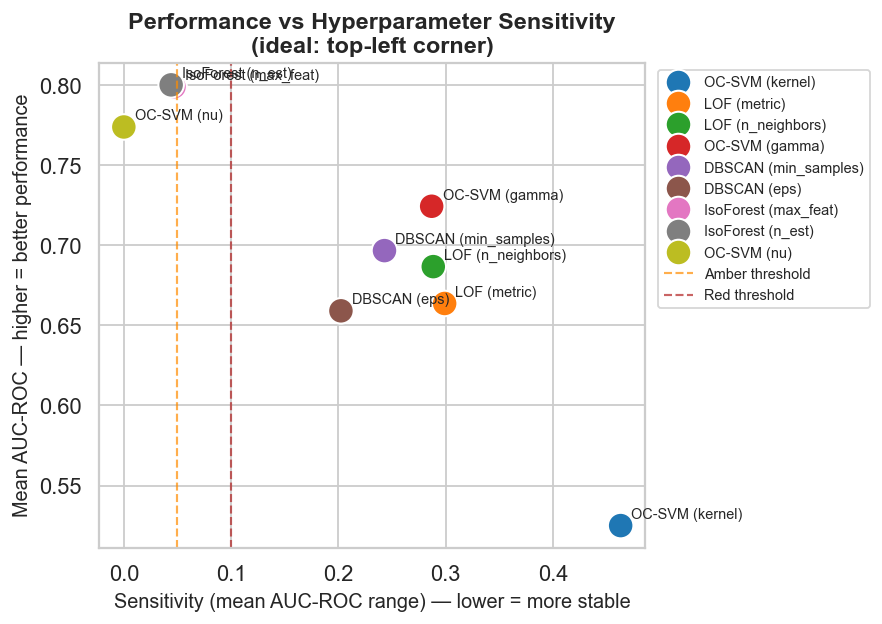

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=stability, x='Mean range', y='Mean AUC-ROC', s=200, hue='Algorithm', palette='tab10', legend=True, ax=ax)

for _, row in stability.iterrows():
    ax.annotate(row['Algorithm'], (row['Mean range'], row['Mean AUC-ROC']), xytext=(6, 4), textcoords='offset points', fontsize=8)

ax.axvline(0.05, color='darkorange', ls='--', lw=1.2, alpha=0.7, label='Amber threshold')
ax.axvline(0.10, color='firebrick', ls='--', lw=1.2, alpha=0.7, label='Red threshold')
ax.set_xlabel('Sensitivity (mean AUC-ROC range) — lower = more stable', fontsize=11)
ax.set_ylabel('Mean AUC-ROC — higher = better performance', fontsize=11)
ax.set_title('Performance vs Hyperparameter Sensitivity\n(ideal: top-left corner)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


Observations:

Isolation Forest (both parameters) sits in the ideal top-left corner - high performance and low sensitivity. It's the only algorithm that is both accurate and easy to tune.

OC-SVM kernel is the worst of both worlds - bottom-right corner, meaning high sensitivity and the lowest mean AUC-ROC. Wrong kernel = bad results and no easy fix.

DBSCAN and LOF cluster in the middle-right: moderate performance but high sensitivity, meaning they can be competitive but only with careful tuning.

---
## Practical Guidelines for Parameter Selection

**Start with Isolation Forest.**

It is the only algorithm that sits in the stable + high-performance corner — n_estimators=100 is sufficient, max_features and contamination 
can be left at defaults. No tuning needed for a solid first baseline.

**When using OC-SVM, kernel and gamma are the only parameters that matter.**

Always use kernel='rbf' — other kernels are either mediocre or dangerous. For gamma, always use gamma='scale' as default and never hardcode 
a fixed numeric value without validation. The nu can be ignored entirely - it has zero effect on ranking metrics and negligible effect on F1.

**LOF requires a n_neighbors sweep - there is no safe universal default.**

The optimal k is strongly dataset-dependent: some datasets peak at k=5, others need k=50. Run a small grid [5, 10, 15, 20, 30] and pick based on validation. Stick to euclidean distance and avoid cosine unless your data is sparse or high-dimensional.

**DBSCAN needs a 2D grid over (eps, min_samples) - always.**

Never tune these parameters independently. Use the k-NN elbow heuristic as a starting point for eps (1.0×auto_eps), set min_samples=5 as initial 
guess, then sweep [0.5, 0.75, 1.0, 1.5] × [3, 5, 7, 10] around that anchor. Be aware that some datasets (graves_fuzzyx) will not respond well to DBSCAN regardless of parameters.